In [2]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import os
from importlib import reload

import FACET2_S2E as qs
from pmd_beamphysics import ParticleGroup

from Experimental_functions import *
import FACET2_S2E_Kladov as kladov

# Helper function to properly reload kladov and all its submodules
def reload_kladov():
    """Reload kladov module and all its submodules"""
    # Reload submodules first
    if 'FACET2_S2E_Kladov.UTILITY_quickstart' in sys.modules:
        reload(sys.modules['FACET2_S2E_Kladov.UTILITY_quickstart'])
    if 'FACET2_S2E_Kladov.functionsForSims' in sys.modules:
        reload(sys.modules['FACET2_S2E_Kladov.functionsForSims'])
    # Then reload the main module
    reload(kladov)
    return kladov

#filepath = str(Path(os.getcwd()).parent)
filepath = "/sdf/group/facet/kladov/FACET2-S2E"
folder = "/sdf/group/facet/kladov/FACET2-S2E/"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
os.system("hostname")

sdfmilan104


0

In [4]:
def get_energy_at_checkpoints(tao, locationsToSave):
    energy_at_checkpoints = []
    for location in locationsToSave:
        energy_at_checkpoints.append(float(np.mean(kladov.getBeamAtElement(tao, location).pz))/1e6)
    return energy_at_checkpoints

# Default sim

Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
Base Tao lattice
CSR off, SC off
[68.6240102579294, 129.32173285036524, 340.30955014224594, 4442.880469000392, 9871.87981788321]


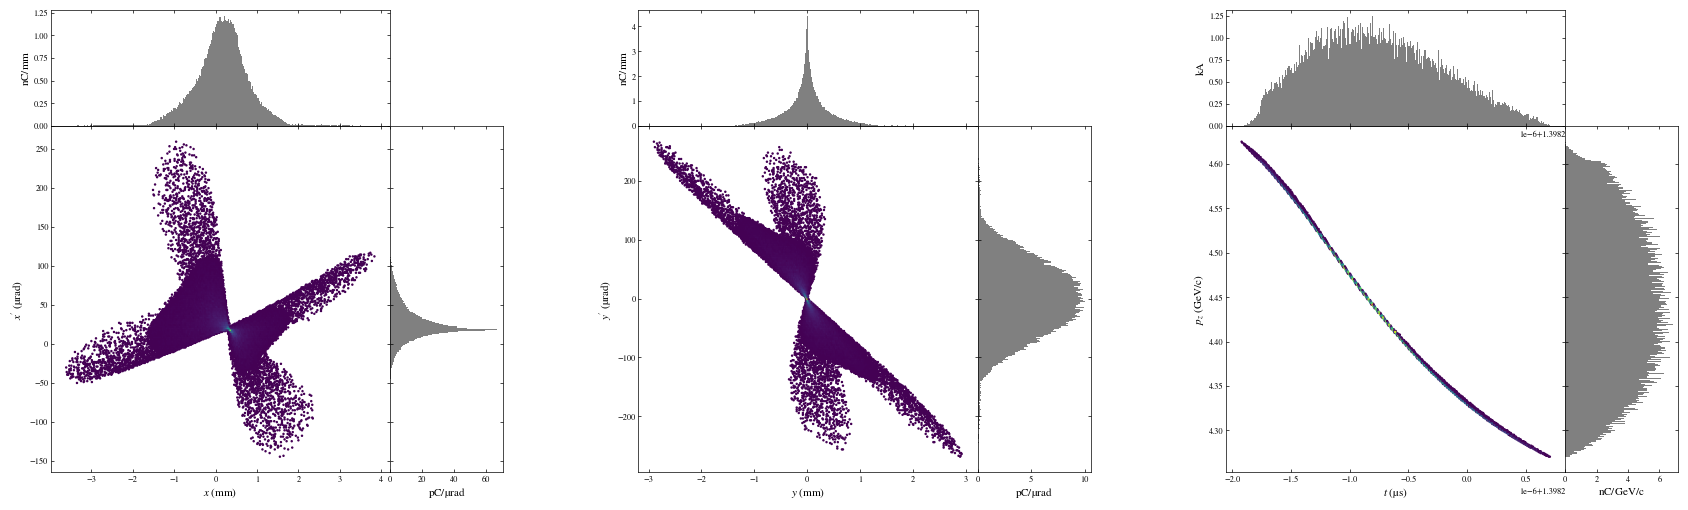

[0.0006743165645092215, 2.8942256924275913e-05, 0.00047361441338634606, 6.377781054771949e-05, 0.0, 83083523.90170887, 5.413647084773904e-13]


In [5]:
# Default .tao lattice
reload_kladov()
tao = kladov.initializeTao()
file = "beams/2024-12-11_Impact_OneBunch/2024-12-11_oneBunch"
kladov.set_beam(tao, folder + file, numMacroParticles = 1e5)

qs.setLinacPhase(tao, "L1", -14)
qs.setLinacGradientAuto(tao, "L1", 212.7*1e6)

kladov.trackBeam(tao)

print(get_energy_at_checkpoints(tao, ["L0AFEND", "L0BFEND", "BC11CBEG", "ENDL2F", "ENDL3F_2"]))

kladov.print_result_from_tao(tao, location="ENDBC14_2", couples=[['x', 'xp'],['y', 'yp'],['t', 'pz']])

Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
Overwriting lattice with setLattice()
No defaults file provided to setLattice(). Using /sdf/group/facet/kladov/FACET2-S2E/setLattice_configs/defaults.yml
CSR off, SC off
[68.62360399209129, 127.82187150136913, 338.81971134457604, 4441.490178548461, 9872.429156861543]


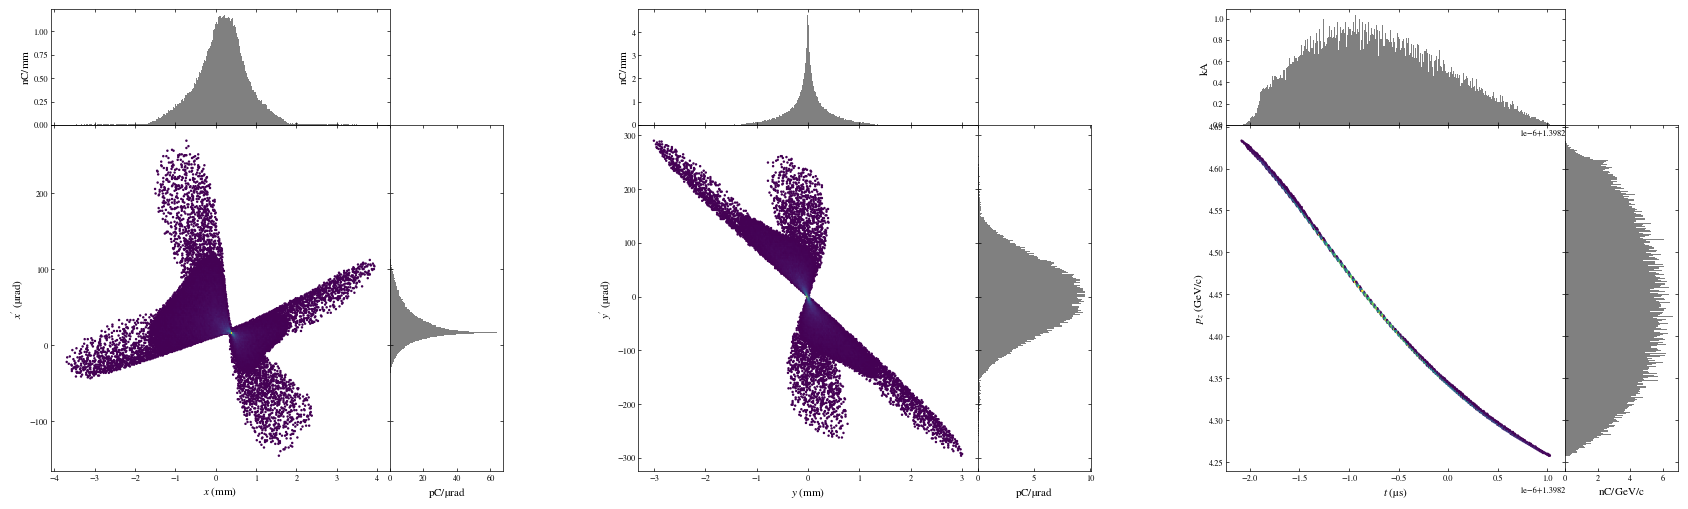

[0.0006881644480052452, 2.9736486712440236e-05, 0.00047597817282547756, 6.760752647938318e-05, 0.0, 87904111.91427042, 6.550395814846834e-13]


In [ ]:
# Default .tao lattice + defaults.yml
reload_kladov()
tao = kladov.initializeTao(loadCustomLatticeTF=True)
file = "beams/2024-12-11_Impact_OneBunch/2024-12-11_oneBunch"
kladov.set_beam(tao, folder + file, numMacroParticles = 1e5)

qs.setLinacPhase(tao, "L1", -14)
qs.setLinacGradientAuto(tao, "L1", 212.7*1e6)

kladov.trackBeam(tao)

print(get_energy_at_checkpoints(tao, ["L0AFEND", "L0BFEND", "BC11CBEG", "ENDL2F", "ENDL3F_2"]))

kladov.print_result_from_tao(tao, location="ENDBC14_2", couples=[['x', 'xp'],['y', 'yp'],['t', 'pz']])

Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
Overwriting lattice with setLattice()
CSR off, SC off
[68.6243437911413, 125.79072837190581, 336.77969612748706, 4438.449022728531, 9854.50529068764]


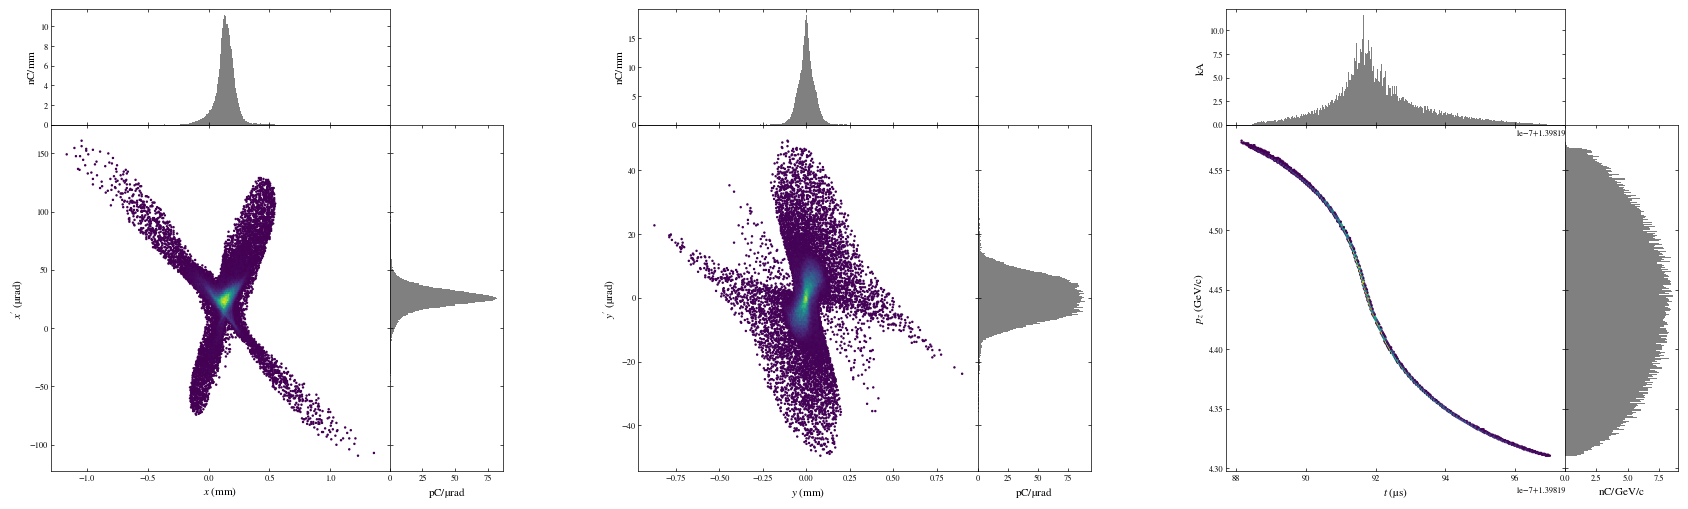

[0.00010465814366906028, 1.6421584455702565e-05, 6.286400866967487e-05, 7.929589831285749e-06, 0.0, 63233493.977319784, 1.3695517104520852e-13]


In [14]:
# Default .tao lattice + defaults.yml + 2024-10-22_oneBunch-Copy1.yml
reload_kladov()
tao = kladov.initializeTao(loadCustomLatticeTF=True, latticeFile="setLattice_configs/2024-10-22_oneBunch-Copy1.yml")
file = "beams/2024-12-11_Impact_OneBunch/2024-12-11_oneBunch"
kladov.set_beam(tao, folder + file, numMacroParticles = 1e5)

qs.setLinacPhase(tao, "L1", -14)
qs.setLinacGradientAuto(tao, "L1", 212.7*1e6)

kladov.trackBeam(tao)

print(get_energy_at_checkpoints(tao, ["L0AFEND", "L0BFEND", "BC11CBEG", "ENDL2F", "ENDL3F_2"]))

kladov.print_result_from_tao(tao, location="ENDBC14_2", couples=[['x', 'xp'],['y', 'yp'],['t', 'pz']])

# Main function

## Basic sim

### Nathan's default

Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
Overwriting lattice with setLattice()
CSR off, SC off
[68.62273285458839, 125.789135158302, 334.11222060677767, 4434.386937143111]


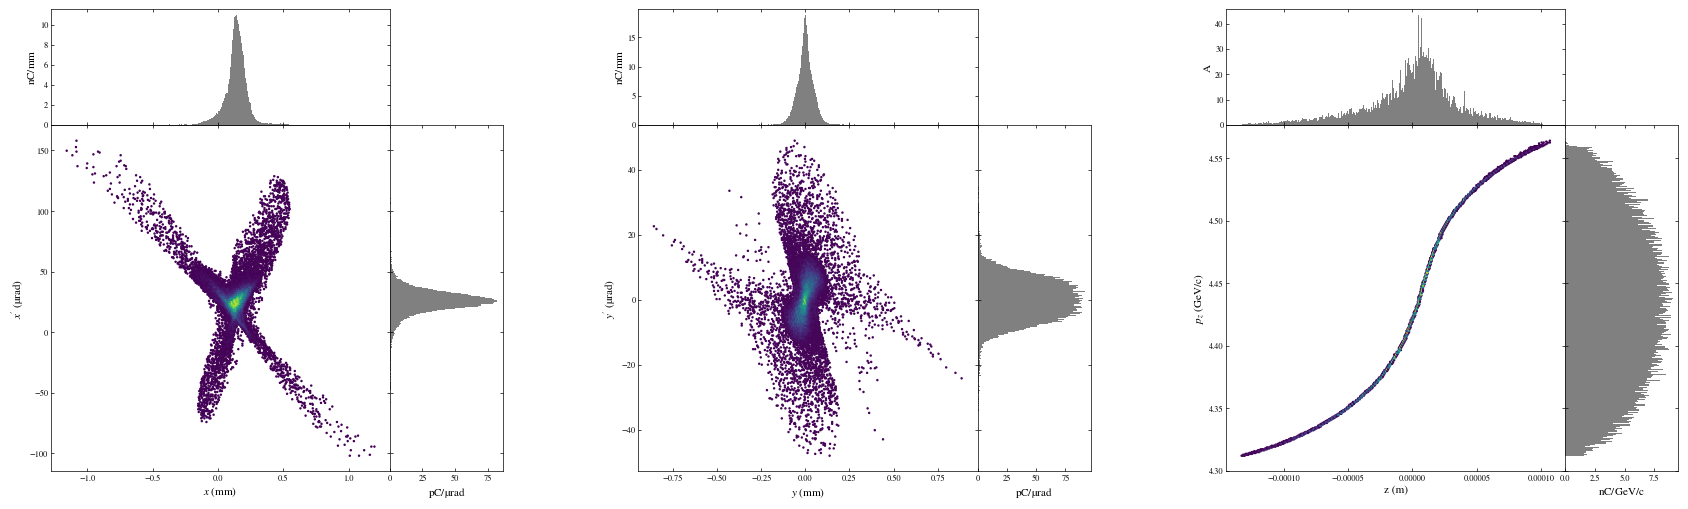

[0.00010525778206175064, 1.6614898481406768e-05, 6.383661168658111e-05, 7.803166525475289e-06, 0.0, 61132860.84628615, 1.2237323767035754e-13]


In [15]:
reload_kladov()
# energy=-1 means to set the beam energy to the energy from the beam file.
tao = kladov.get_tao_from_experiment(start='L0AFEND', filepath=filepath, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml", verbose=True,
                file_ext = folder + "beams/2024-12-11_Impact_OneBunch/2024-12-11_oneBunch", N_to_use_from_file=5e4, sr_wakes_on=True, lr_wakes_on=True, run=False,
                energy=-1, tune_dipoles_to_125_335_4500_10000_MeV=False)

tao = kladov.run_initialized_sim(tao, start='L0AFEND', finish='ENDBC14_2')
print(get_energy_at_checkpoints(tao, ["L0AFEND", "L0BFEND", "BC11CBEG", "ENDL2F"]))

kladov.print_result_from_tao(tao, location="ENDBC14_2", couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], z_from_t=True)

### With bunch energy corresponding to the initial lattice energy

Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
Overwriting lattice with setLattice()


CSR off, SC off
[63.995228064207716, 121.16811971922243, 328.938095701852, 4517.6606314693645]


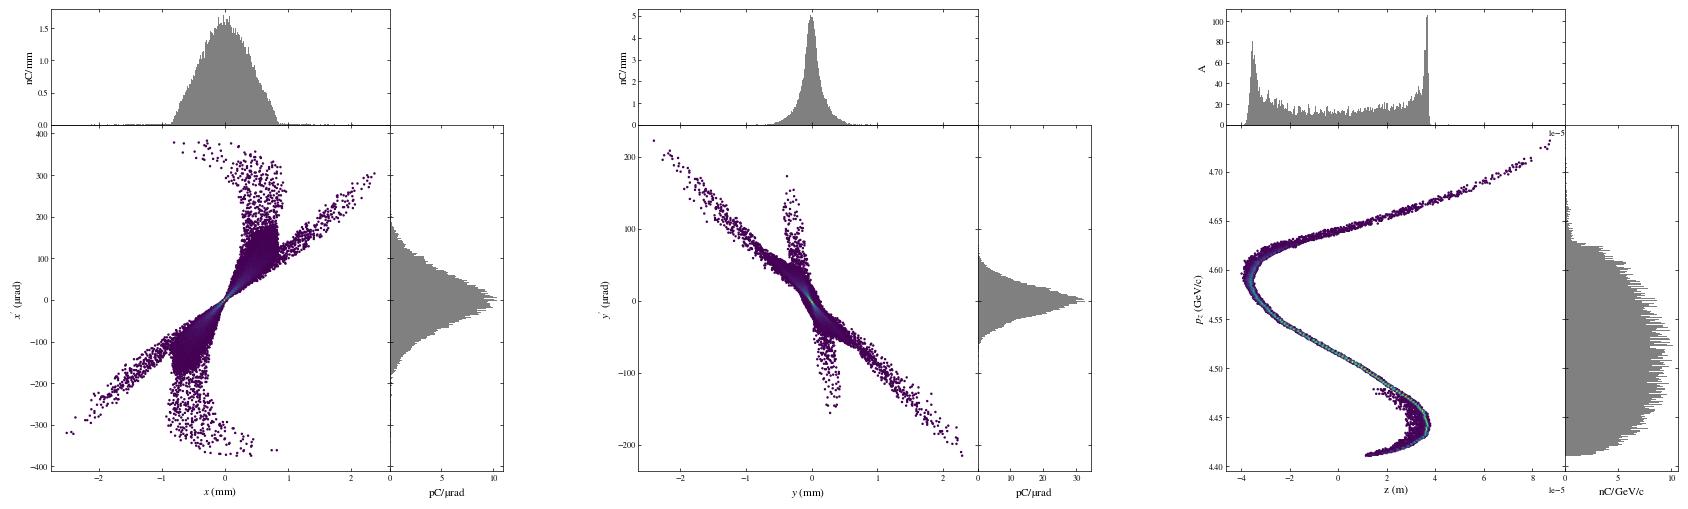

[0.0003903353846427822, 7.464917251556672e-05, 0.00022964974988946035, 2.5852383733070367e-05, 0.0, 56810285.3124938, 8.7711632664845e-14]


In [ ]:
reload_kladov()
tao = kladov.get_tao_from_experiment(start='L0AFEND', filepath=filepath, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml", verbose=True,
                file_ext = folder + "beams/2024-12-11_Impact_OneBunch/2024-12-11_oneBunch", N_to_use_from_file=5e4, sr_wakes_on=True, lr_wakes_on=True, run=False)

tao = kladov.run_initialized_sim(tao, start='L0AFEND', finish='ENDBC14_2')
print(get_energy_at_checkpoints(tao, ["L0AFEND", "L0BFEND", "BC11CBEG", "ENDL2F"]))

kladov.print_result_from_tao(tao, location="ENDBC14_2", couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], z_from_t=True)

## Lattice change according to a DAQ-saved experiment

### Default adjustments (no correctors)

Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
Overwriting lattice with setLattice()
CSR off, SC off
PR11375
[87.50876412309107, 124.6764509567827, 332.4954637559039, 4523.768328723861, 9940.852247301173]


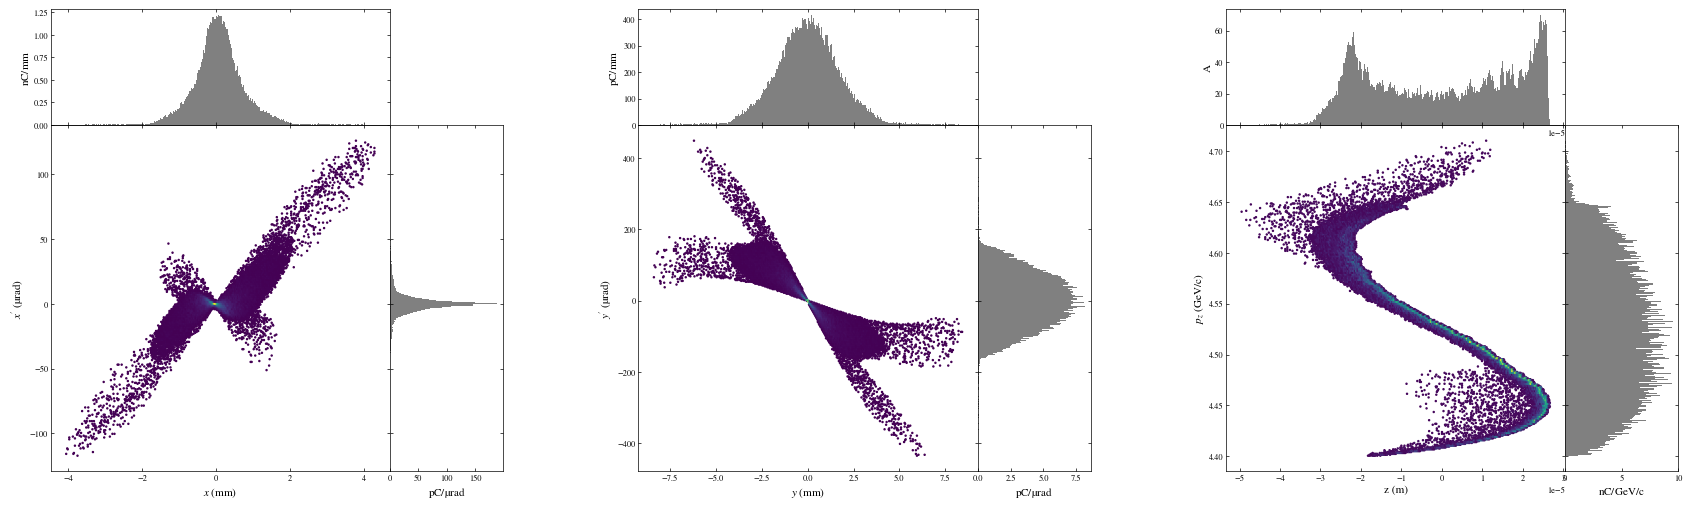

[0.0007230889725676779, 1.54838069578304e-05, 0.0017785124352202148, 8.057915215522232e-05, 0.0, 0.01248014196074264, 5.98847828952375e-14]


In [6]:
# Wakefields are turned on here
reload_kladov()
experiment="BEAMPHYS"
scan_number="14438"
date="/2026/20260121"
tao = kladov.get_tao_from_experiment(experiment=experiment, scan_number=scan_number, date=date, start='L0AFEND', finish='ENDL3F_2', filepath=filepath,
                                    file_ext = folder + "beams/2024-12-11_Impact_OneBunch/2024-12-11_oneBunch", N_to_use_from_file=5e4,
                                    verbose=True, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml", sr_wakes_on=True, lr_wakes_on=True)

print(get_energy_at_checkpoints(tao, ["L0AFEND", "L0BFEND", "BC11CBEG", "ENDL2F", "ENDL3F_2"]))
kladov.print_result_from_tao(tao, location="ENDBC14_2", couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], moments=True, sliceEnergyMoment=True, energyInDelta=True, z_from_t=True)

Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
Overwriting lattice with setLattice()
CSR off, SC off
PR11375
[87.51171830645008, 124.97879886285607, 334.9356406641327, 4507.530064950364, 10007.48927505129]


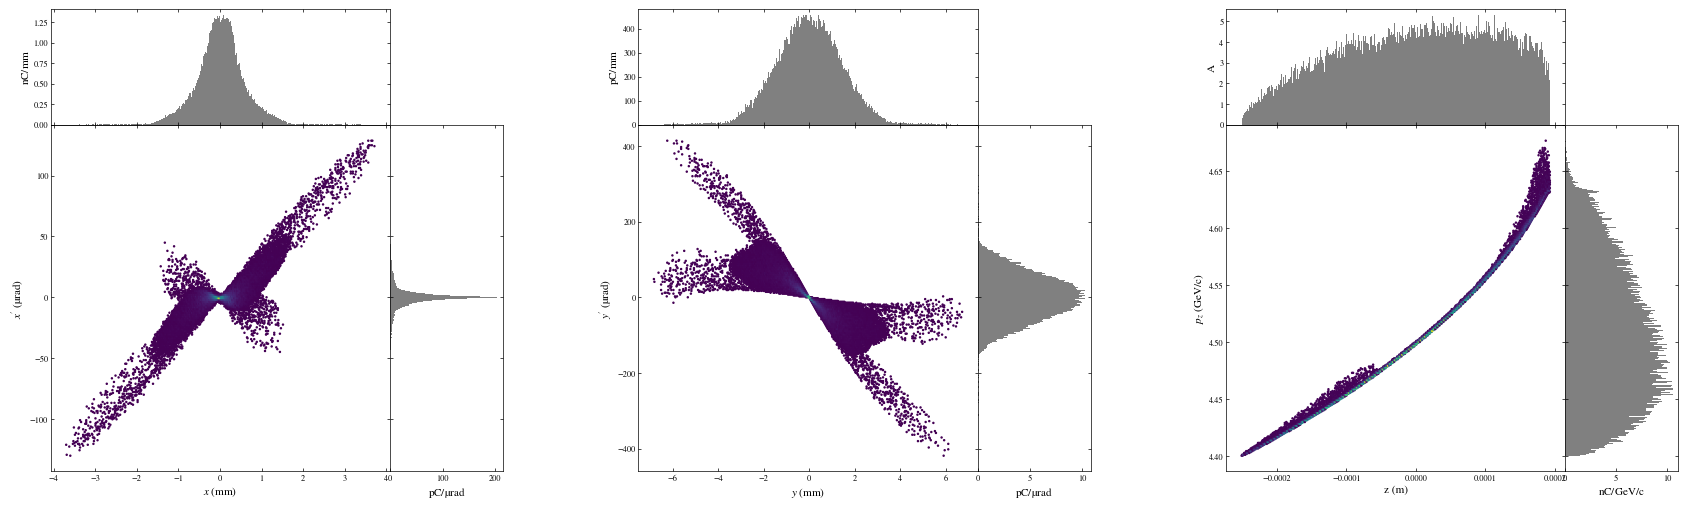

[0.0006370874307731778, 1.6565438160874982e-05, 0.0014944826559882135, 6.707584785877477e-05, 0.0, 7.010235502128285e-05, 3.739542985402291e-13]


In [17]:
# Wakefields are turned off here
reload_kladov()
experiment="BEAMPHYS"
scan_number="14438"
date="/2026/20260121"
tao = kladov.get_tao_from_experiment(experiment=experiment, scan_number=scan_number, date=date, start='L0AFEND', finish='ENDL3F_2', filepath=filepath,
                                    file_ext = folder + "beams/2024-12-11_Impact_OneBunch/2024-12-11_oneBunch", N_to_use_from_file=5e4,
                                    verbose=True, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml")

print(get_energy_at_checkpoints(tao, ["L0AFEND", "L0BFEND", "BC11CBEG", "ENDL2F", "ENDL3F_2"]))
kladov.print_result_from_tao(tao, location="ENDBC14_2", couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], moments=True, sliceEnergyMoment=True, energyInDelta=True, z_from_t=True)

### Correctors

PR11375


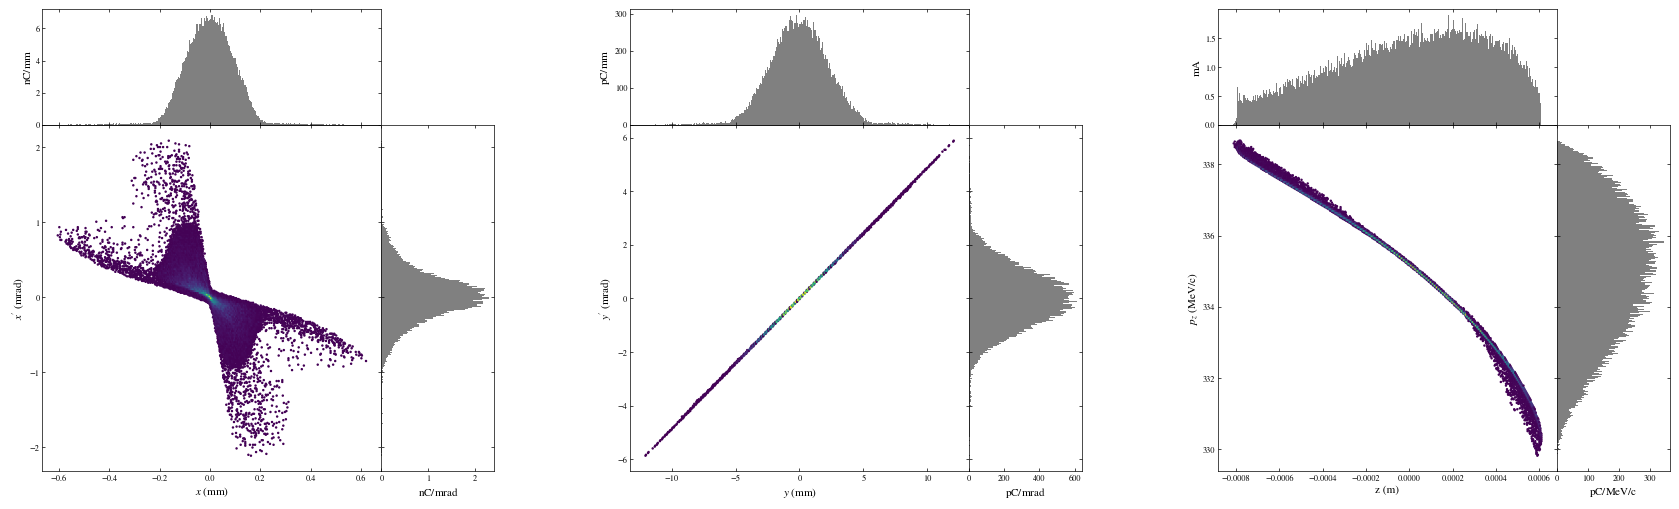

[0.00010306617234479061, 0.00037283894210963126, 0.0023771626717934303, 0.0011541067581299009, 0.0, 1817057.1845753405, 1.1727469600552403e-12]


In [7]:
reload_kladov()
experiment="BEAMPHYS"
scan_number="14438"
date="/2026/20260121"
tao = kladov.get_tao_from_experiment(experiment=experiment, scan_number=scan_number, date=date,
                                     start='L0AFEND', finish='PR11375', filepath=filepath, file_ext = folder + "beams/2024-12-11_Impact_OneBunch/2024-12-11_oneBunch",
                                     N_to_use_from_file=5e4, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml")

kladov.print_result_from_tao(tao, location="PR11375", couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], z_from_t=True)

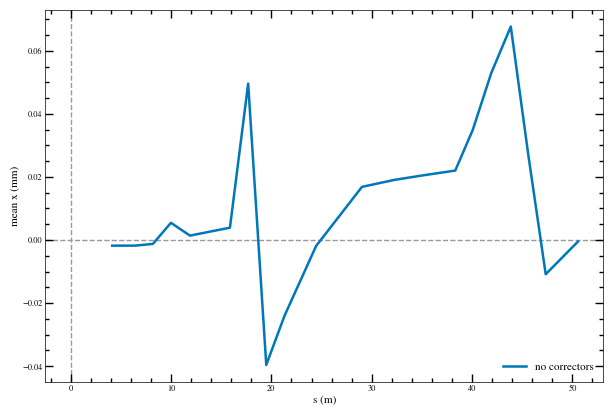

In [ ]:
s = tao.bunch_comb("s")
mean_x = tao.bunch_comb("x")
kladov.make_a_plot(s, mean_x*1e3, x_label="s (m)", y_label="mean x (mm)", label="no correctors")

PR11375


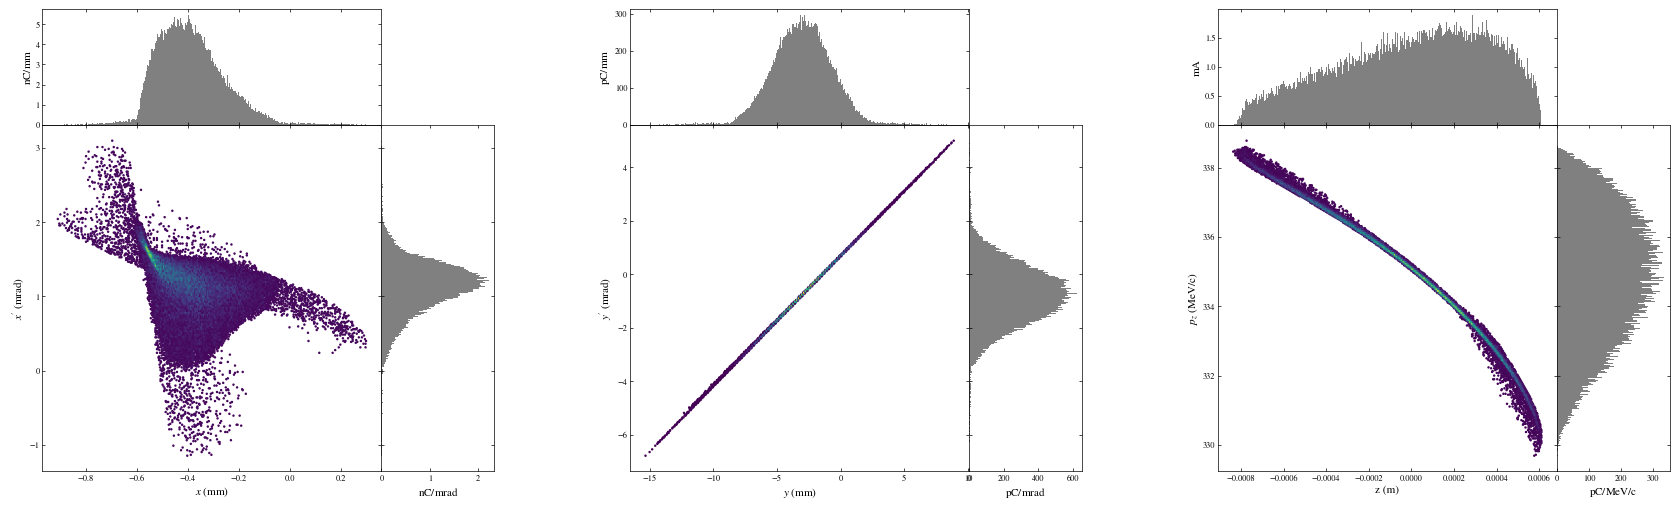

[0.0001328077799327549, 0.00038706526465673893, 0.0023900569332350784, 0.0011600366637252823, 0.0, 1825145.7281038782, 1.1677174465952858e-12]


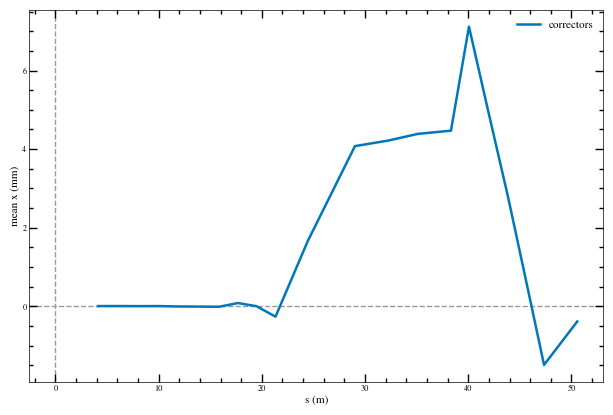

In [20]:
reload_kladov()
experiment="BEAMPHYS"
scan_number="14438"
date="/2026/20260121"
tao = kladov.get_tao_from_experiment(experiment=experiment, scan_number=scan_number, date=date, correctors_from_beg=False, correctors_coef=-1/10,
                                     start='L0AFEND', finish='PR11375', filepath=filepath, file_ext = folder + "beams/2024-12-11_Impact_OneBunch/2024-12-11_oneBunch",
                                     N_to_use_from_file=5e4, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml")

kladov.print_result_from_tao(tao, location="PR11375", couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], z_from_t=True)

s = tao.bunch_comb("s")
mean_x = tao.bunch_comb("x")
kladov.make_a_plot(s, mean_x*1e3, x_label="s (m)", y_label="mean x (mm)", label="correctors")

PR11375


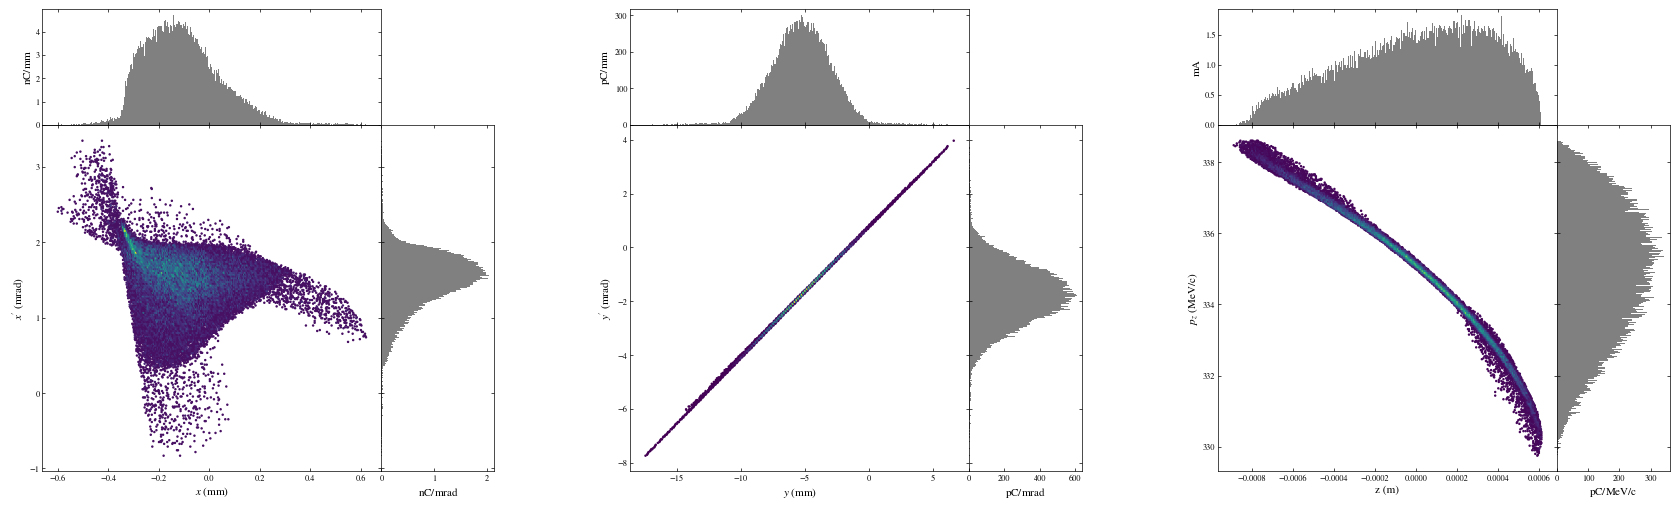

[0.00015113399180808446, 0.00040119862581137057, 0.0023949741511076206, 0.0011635091142112506, 0.0, 1820466.4447617999, 1.1672268465272838e-12]


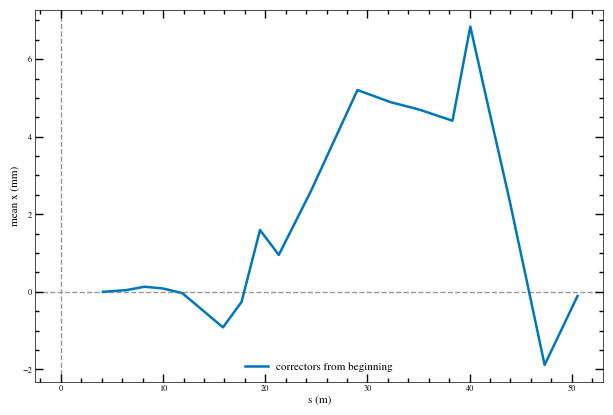

In [21]:
reload_kladov()
experiment="BEAMPHYS"
scan_number="14438"
date="/2026/20260121"
tao = kladov.get_tao_from_experiment(experiment=experiment, scan_number=scan_number, date=date, correctors_from_beg=True, correctors_coef=-1/10,
                                     start='L0AFEND', finish='PR11375', filepath=filepath, file_ext = folder + "beams/2024-12-11_Impact_OneBunch/2024-12-11_oneBunch",
                                     N_to_use_from_file=5e4, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml")

kladov.print_result_from_tao(tao, location="PR11375", couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], z_from_t=True)

s = tao.bunch_comb("s")
mean_x = tao.bunch_comb("x")
kladov.make_a_plot(s, mean_x*1e3, x_label="s (m)", y_label="mean x (mm)", label="correctors from beginning")

## Check the basic automatic bunch edits

A user-defined bunch has non-zero <z> and <t> (in this example)
The bunch is edited by "get_tao_from_experiment()" according to what user wants (moments/means) and is written to temp_beam/temp.h5
The bunch is then edited by "set_beam()". z is always set to 0. t is set to 0 by default, but can be changed with timeCenterTF=False

In [9]:
reload_kladov()
tao = kladov.get_tao_from_experiment(start='L0AFEND', filepath=filepath,
                                     file_ext = folder + "beams/2024-12-11_Impact_OneBunch/2024-12-11_oneBunch", N_to_use_from_file=5e4,
                                    run=False, verbose=True, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml", sr_wakes_on=True, lr_wakes_on=True)

Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
Overwriting lattice with setLattice()
CSR off, SC off


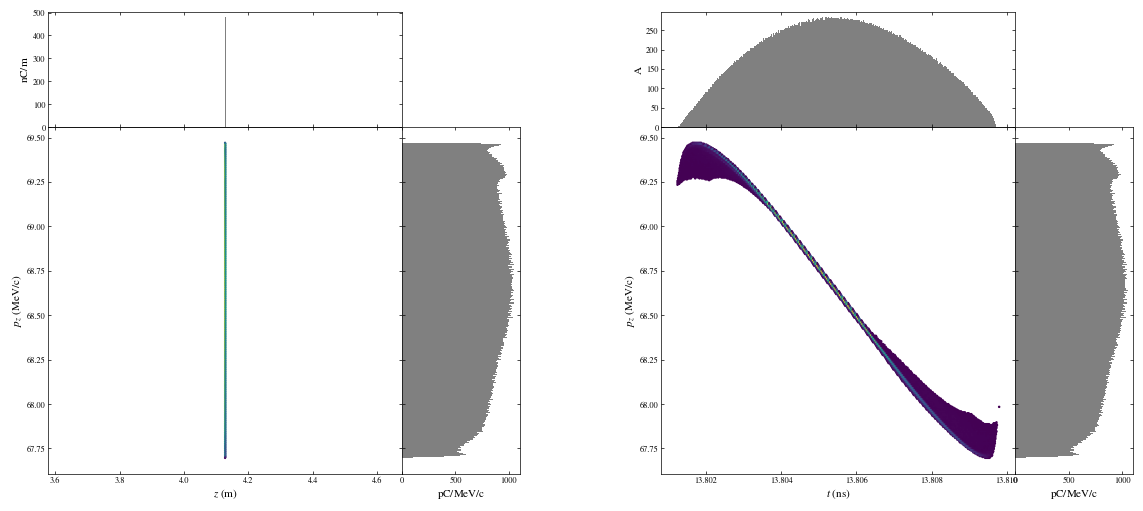

/sdf/group/facet/kladov/miniconda3/envs/bmad-qpad-dev/lib/python3.13/site-packages/scipy/_lib/_util.py:951: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return fun(*args, **kwargs)


[0.0014260284280795971, 0.00037094068974860014, 0.0014260933493291925, 0.0003709612984454537, 8.881784197001252e-16, 484976.6573567925, 1.9149571967784104e-12]


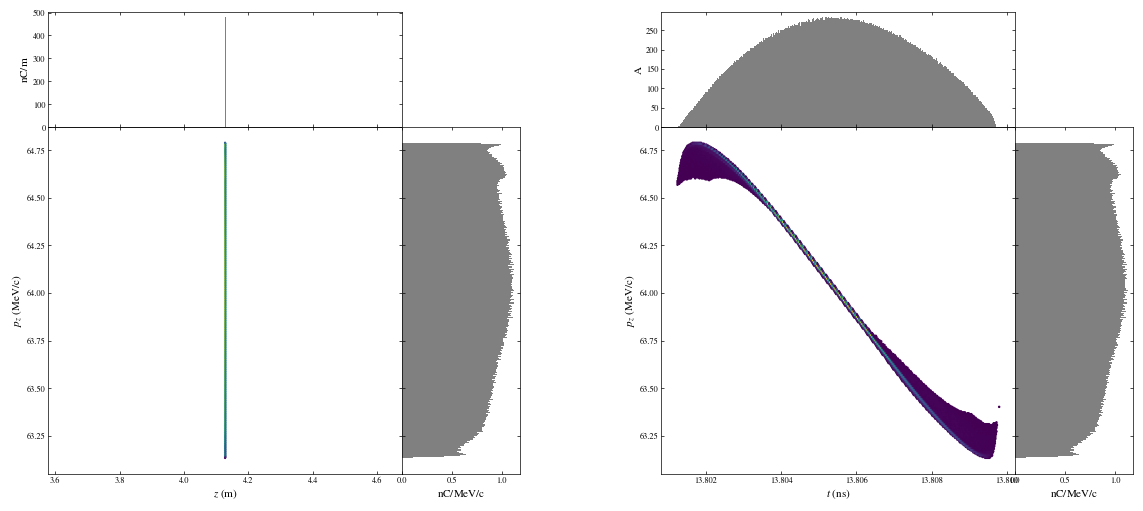

[0.0014260284280795971, 0.000397749508744005, 0.0014260933493291925, 0.0003977716068833487, 8.881784197001252e-16, 452286.404477533, 1.9149571967784104e-12]


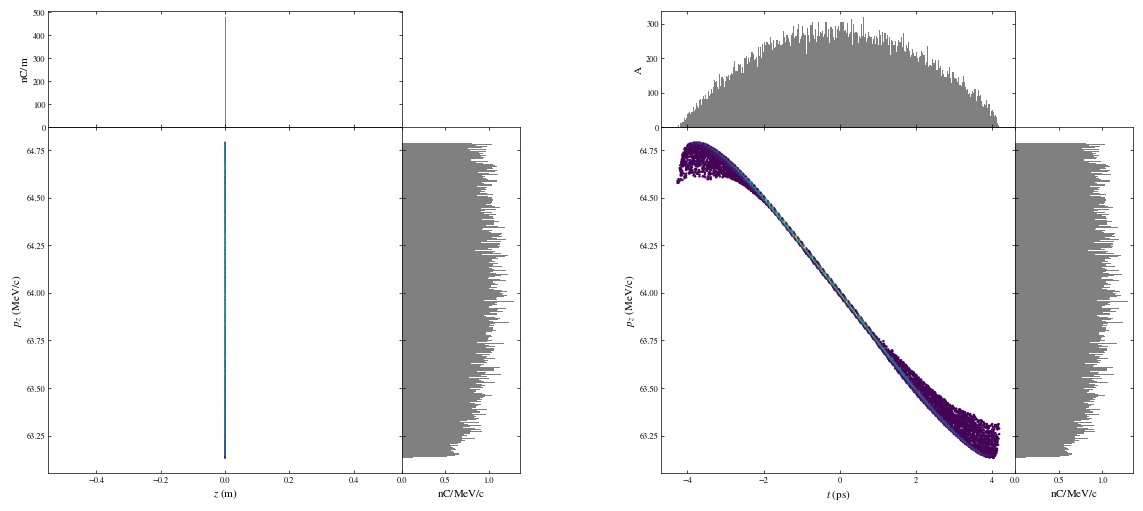

[0.0014263263672816397, 0.0003976272814947398, 0.0014348090232049538, 0.000399879600539917, 0.0, 452968.41971026006, 1.917890840386812e-12]


In [10]:
kladov.print_result_from_file(folder + "beams/2024-12-11_Impact_OneBunch/2024-12-11_oneBunch.h5", couples=[['z', 'pz'],['t','pz']])
kladov.print_result_from_file(folder +"temp_beam/temp.h5", couples=[['z', 'pz'],['t','pz']])
kladov.print_result_from_file(folder +"temp_beam/temp_e.h5", couples=[['z', 'pz'],['t','pz']])

## Cavity energy adjustments + Bends

In this section, I added a line to the run_initialized_sim() function to print out the < x > inside of the dogleg.
If you execute the cells in this section, you will not get the "< x > inside of the dogleg:" message

### Energy tuned to 125, 335, 4500 and 10000. Run with dipole treatment

PR11375


<x> inside of the dogleg: 1.47917607997114e-05
[87.52994218410235, 124.99760550182853, 334.8875501812061]
[-2.23782772e-05 -7.30727118e-06]


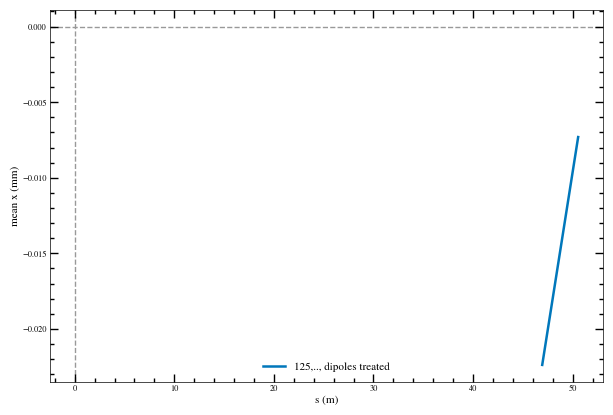

In [65]:
# Shouldn't have any effect because the dipole treatment tunes the energies to 125, 335, 4500, 10000.
reload_kladov()
experiment="BEAMPHYS"
scan_number="14438"
date="/2026/20260121"
tao = kladov.get_tao_from_experiment(experiment=experiment, scan_number=scan_number, date=date, start='L0AFEND', finish='PR11375', filepath=filepath,
                                     file_ext = folder + "beams/2024-12-11_Impact_OneBunch/2024-12-11_oneBunch", desired_P0Cs_MeV=[125, 335, None, None],
                                     N_to_use_from_file=5e2, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml")

#print(get_energy_at_checkpoints(tao, ["L0AFEND", "L0BFEND", "BC11CBEG", "ENDL2F", "ENDL3F_2"]))
print(get_energy_at_checkpoints(tao, ["L0AFEND", "L0BFEND", "BC11CBEG"]))

s = tao.bunch_comb("s")
mean_x = tao.bunch_comb("x")
print(mean_x)
# Note that the bunch_comb returns only the BC11CEND -> PR11375 part of the linac because running with desired_P0Cs_MeV splits the evaluation into multiple runs.
kladov.make_a_plot(s, mean_x*1e3, x_label="s (m)", y_label="mean x (mm)", label="125,.., dipoles treated")

### Energy tuned to 120, 335, 4500, 10000. No dipole treatment

PR11375
[87.51593121872108, 119.98438132189371, 334.9438567356925]
<x> inside of the dogleg: 4.13585457471119e-05


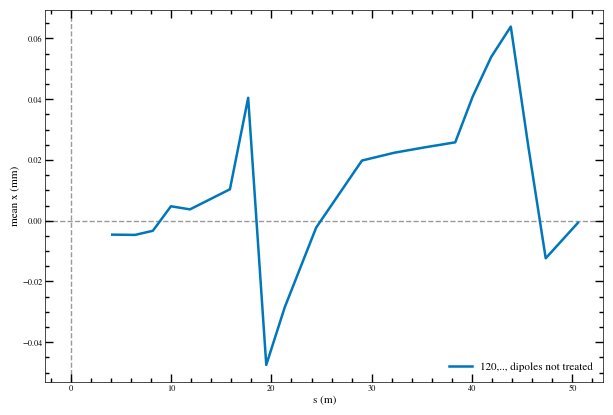

In [64]:
# The <x> should be 0 because the field is automatically adjusted to keep the angle the same for the changed lattice energy.
# The R51 of the dipole should change because the magnetic field is changed (to keep the angle the same for the changed lattice energy).
# If the bends are set to FIELD_MASTER=True, the situation is similar: the R51 is not changed,
# but the whole downstream lattice is turned to match the new angle, so the <x> is still 0.
reload_kladov()
experiment="BEAMPHYS"
scan_number="14438"
date="/2026/20260121"
tao = kladov.get_tao_from_experiment(experiment=experiment, scan_number=scan_number, date=date, start='L0AFEND', finish='PR11375', filepath=filepath,
                                     file_ext = folder + "beams/2024-12-11_Impact_OneBunch/2024-12-11_oneBunch", run=False,
                                     N_to_use_from_file=5e4, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml")

# Change only L0B to not change the L0AFEND energy (so that the bunch is matched to the lattice energy).
# Could match it explicitly (this is done in the main function), but it is better to demonstrate the change_only_L0B option use case here.
tao = kladov.tune_to_P0Cs(tao, desired_P0Cs_MeV=[120, 335, 4500, 10000], change_only_L0B=True)
tao = kladov.run_initialized_sim(tao, start='L0AFEND', finish='PR11375')
print(get_energy_at_checkpoints(tao, ["L0AFEND", "L0BFEND", "BC11CBEG"]))
#print(f'<x> inside of the dogleg: {float(np.mean(kladov.getBeamAtElement(tao, "BPM10731").x))}')
print(f'<x> inside of the dogleg: {tao.bunch_params("BPM10731")["centroid_vec_1"]}')

s = tao.bunch_comb("s")
mean_x = tao.bunch_comb("x")
kladov.make_a_plot(s, mean_x*1e3, x_label="s (m)", y_label="mean x (mm)", label="120,.., dipoles not treated")

### Energy tuned to 120, 335, 4500, 10000. Dipoles are treated

PR11375
<x> inside of the dogleg: 0.0109859470379692
[87.51451215548269, 119.98277882561376, 334.8233943478631]


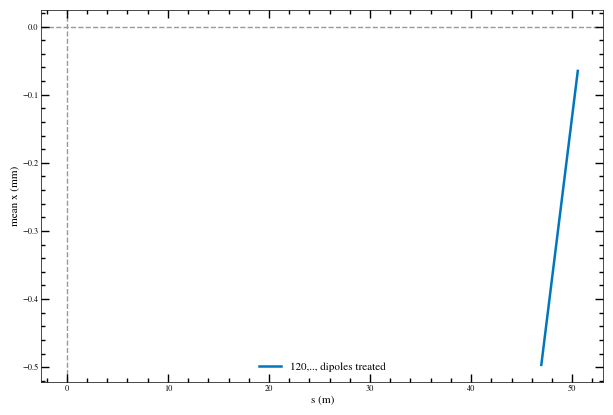

In [7]:
# The <x> should be non-0 (the field is fixed, the geometry is fixed).
# The R51 of the dipole is fixed.
reload_kladov()
experiment="BEAMPHYS"
scan_number="14438"
date="/2026/20260121"
tao = kladov.get_tao_from_experiment(experiment=experiment, scan_number=scan_number, date=date, start='L0AFEND', finish='PR11375', filepath=filepath,
                                     file_ext = folder + "beams/2024-12-11_Impact_OneBunch/2024-12-11_oneBunch", desired_P0Cs_MeV=[120, 335, None, None],
                                     N_to_use_from_file=5e4, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml")

print(get_energy_at_checkpoints(tao, ["L0AFEND", "L0BFEND", "BC11CBEG"]))

s = tao.bunch_comb("s")
mean_x = tao.bunch_comb("x")
kladov.make_a_plot(s, mean_x*1e3, x_label="s (m)", y_label="mean x (mm)", label="120,.., dipoles treated")

### Saved algorithm to plot < x > with s mask

[ 4.1274477   6.4082753   8.1818773   9.98144488 11.87950998 13.70351096
 15.86301552 17.68067962]


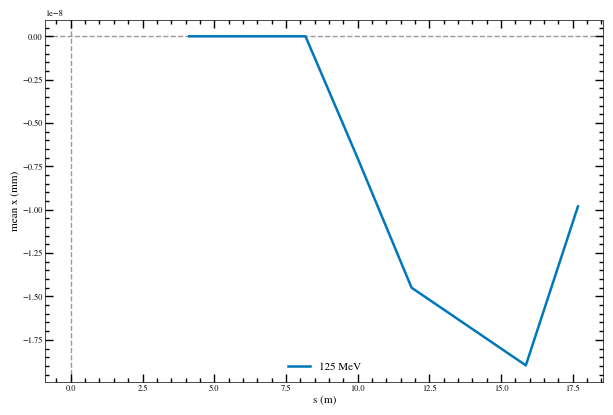

In [34]:
s = tao.bunch_comb("s")
mean_x = tao.bunch_comb("x")

s1 = tao.lat_list("L0AFEND", "ele.s")
s2 = tao.lat_list("BX0FEND", "ele.s")

mask = (s >= s1) & (s <= s2)

s_part = s[mask]
x_part = mean_x[mask]

print(s_part)

kladov.make_a_plot(s_part, x_part*1e3, x_label="s (m)", y_label="mean x (mm)", label="125 MeV")

## Keep the lattice for the correct dipole setup, but change the bunch energy at checkpoints (used this before, but now not so much)

In [12]:
reload_kladov()
experiment="BEAMPHYS"
scan_number="14438"
date="/2026/20260121"
tao = kladov.get_tao_from_experiment(experiment=experiment, scan_number=scan_number, date=date, start='L0AFEND', finish='ENDL3F_2', filepath=filepath,
                                    file_ext = folder + "beams/2024-12-11_Impact_OneBunch/2024-12-11_oneBunch", N_to_use_from_file=5e4,
                                    verbose=True, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml", run=False)

Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
Overwriting lattice with setLattice()
CSR off, SC off
PR11375


[87.51321481329758, 120.0, 330.9145184145327, 4637.46068115567, 10135.355052311414]


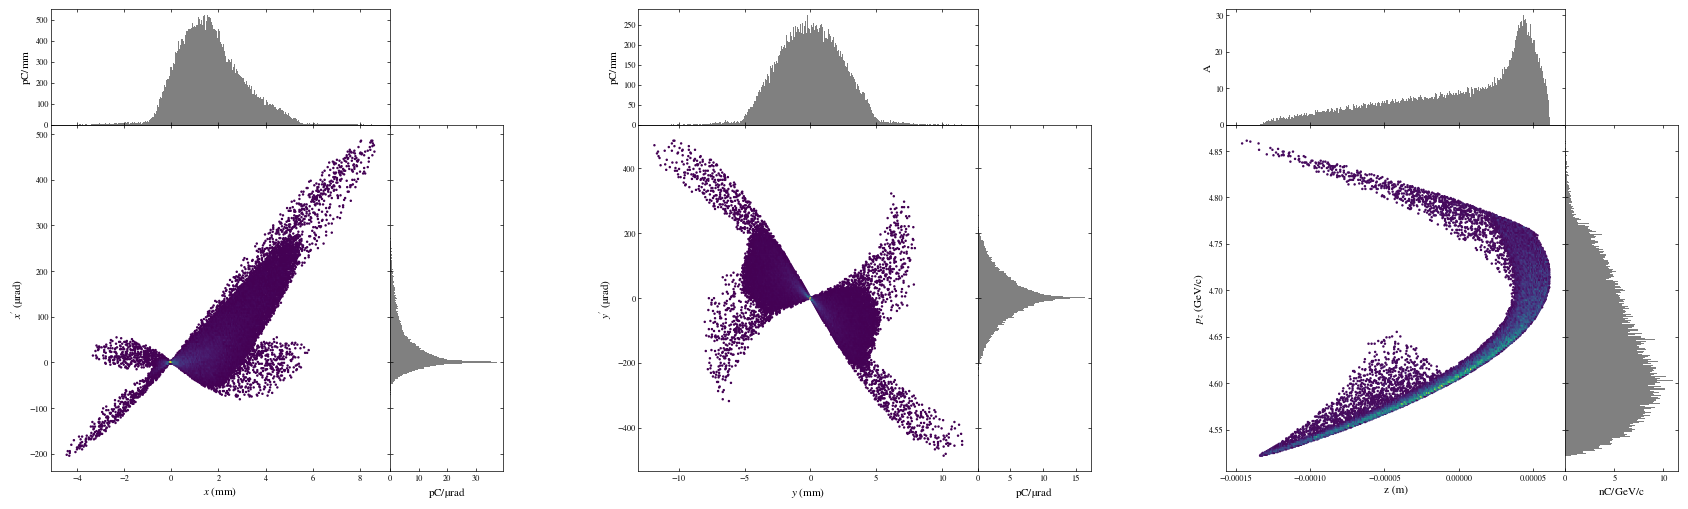

[0.001421099759847883, 6.81172335186451e-05, 0.0024567761032188895, 8.541159823197477e-05, 0.0, 0.009852817651992344, 1.6108337370590038e-13]


In [13]:
tao = kladov.run_initialized_sim_edit_bunch_energy(tao, start='L0AFEND', finish='ENDL3F_2', edited_bunch_energy_at_checkpoints_MeV=[120,None,None,None])

print(get_energy_at_checkpoints(tao, ["L0AFEND", "BX0FBEG", "BC11CBEG", "ENDL2F", "ENDL3F_2"]))
kladov.print_result_from_tao(tao, location="ENDBC14_2", couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], moments=True, sliceEnergyMoment=True, energyInDelta=True, z_from_t=True)

In [14]:
print(f'<x> inside of the dogleg: {tao.bunch_params("BPM10731")["centroid_vec_1"]}')

<x> inside of the dogleg: 0.0109494270448818


Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
Overwriting lattice with setLattice()
CSR off, SC off
PR11375
[87.51244529060556, 120.0, 330.9150094889185, 4637.532978455052, 10135.42807700905]
<x> inside of the dogleg: 0.0109494811044023


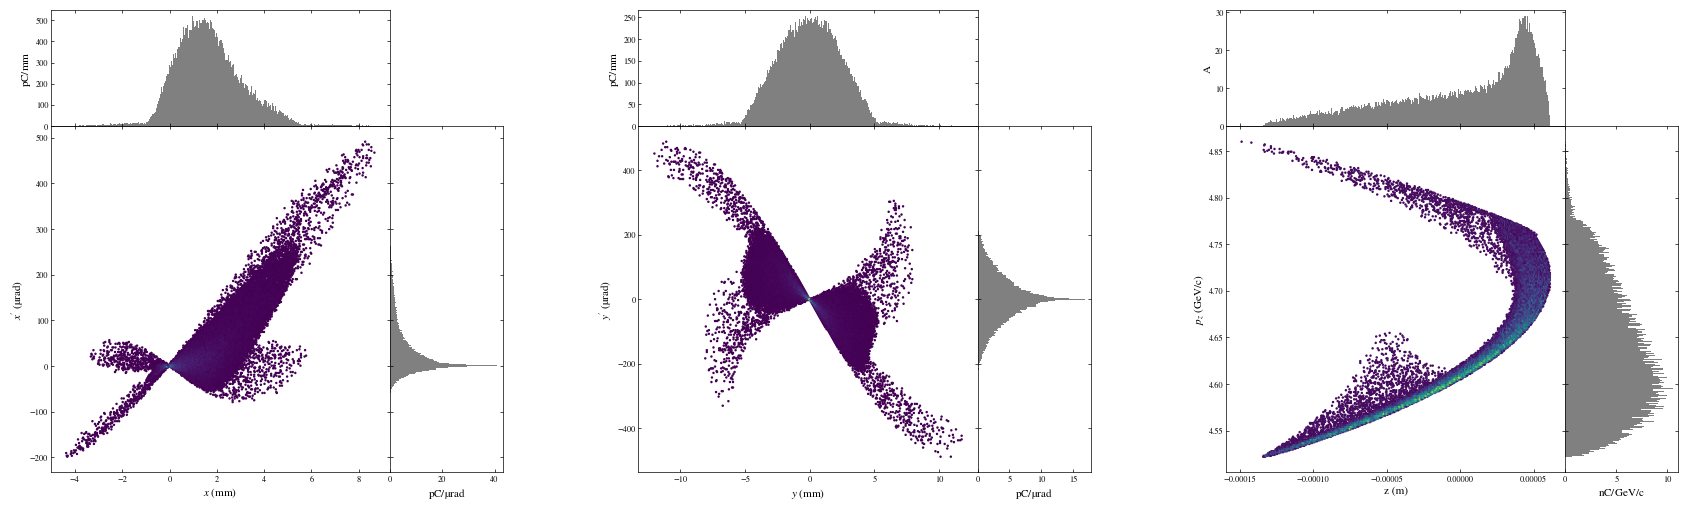

[0.0014185405509946393, 6.784339138033528e-05, 0.002480300511159409, 8.598723505244761e-05, 0.0, 0.008767996080680358, 1.6097832223113756e-13]


In [11]:
reload_kladov()
experiment="BEAMPHYS"
scan_number="14438"
date="/2026/20260121"
tao = kladov.get_tao_from_experiment(experiment=experiment, scan_number=scan_number, date=date, start='L0AFEND', finish='ENDL3F_2', filepath=filepath,
                                    file_ext = folder + "beams/2024-12-11_Impact_OneBunch/2024-12-11_oneBunch", N_to_use_from_file=5e4,
                                    verbose=True, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml",
                                    run=True, edited_bunch_energy_at_checkpoints_MeV=[120,None,None,None])

print(get_energy_at_checkpoints(tao, ["L0AFEND", "BX0FBEG", "BC11CBEG", "ENDL2F", "ENDL3F_2"]))
print(f'<x> inside of the dogleg: {tao.bunch_params("BPM10731")["centroid_vec_1"]}')
kladov.print_result_from_tao(tao, location="ENDBC14_2", couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], moments=True, sliceEnergyMoment=True, energyInDelta=True, z_from_t=True)

## Energy Feedback on beam: track the beam -> change the cavity voltages -> track -> repeat. Replicates the real-world feedback

#### The function iteratively changes the cavities and retrack the bunch from the very beginning to the next checkpoint. Returned tao has the corrected cavity voltages and is ready to be tracked (can be done with run=True too)

In [15]:
reload_kladov()
experiment="BEAMPHYS"
scan_number="14438"
date="/2026/20260121"
tao = kladov.get_tao_from_experiment(experiment=experiment, scan_number=scan_number, date=date, start='L0AFEND', finish='ENDL3F_2', filepath=filepath,
                                    file_ext = folder + "beams/2024-12-11_Impact_OneBunch/2024-12-11_oneBunch", N_to_use_from_file=5e4,
                                    verbose=True, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml", sr_wakes_on=True, lr_wakes_on=True,
                                    run=False, energy_edit_on_beam=True, desired_beam_energies_for_the_feedback=[125e6,335e6,4500e6,10000e6])

Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
Overwriting lattice with setLattice()
CSR off, SC off
PR11375
P0C now: [125000000.0, 335000000.0, 4500000000.0, 10000000000.0]
beam to BX0FBEG: [124682556.46323225]
edited P0C BX0FBEG: 125319872.6997839
beam to BC11CBEG: [124998091.34778894, 332814921.906647]
edited P0C BC11CBEG: 337527919.5540179
beam to ENDL2F: [124998015.41469845, 335024854.2142031, 4525663643.669156]
edited P0C ENDL2F: 4476975880.686487
beam to ENDL3F_2: [124996661.85751668, 335023681.858153, 4499848660.330273, 9917345627.387142]
edited P0C ENDL3F_2: 10060888521.12604


[87.73035986422484, 124.9981081421935, 335.0229368315733, 4499.836392313701, 10001.352004454822]


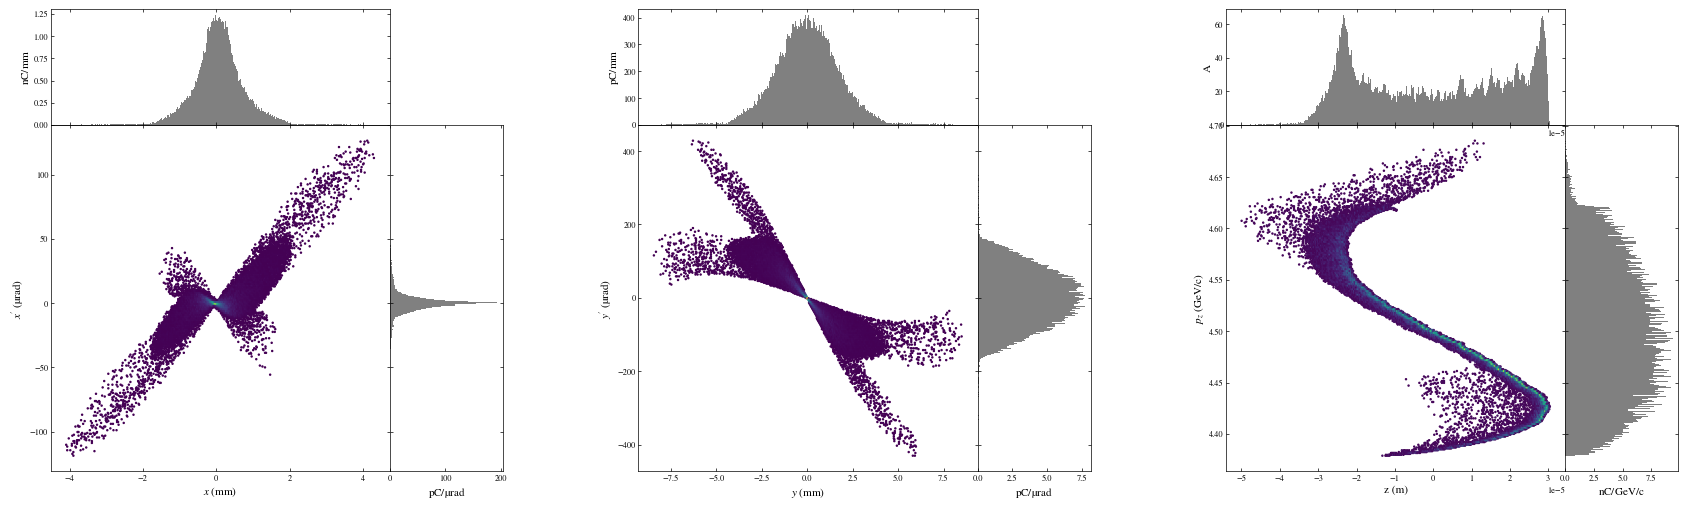

[0.0007217959870501284, 1.536237234628144e-05, 0.0017833075830562175, 8.085847668606432e-05, 0.0, 0.010673526110388772, 6.544367549722984e-14]


In [16]:
tao = kladov.run_initialized_sim(tao, start='L0AFEND', finish='ENDL3F_2')

print(get_energy_at_checkpoints(tao, ["L0AFEND", "L0BFEND", "BC11CBEG", "ENDL2F", "ENDL3F_2"]))
kladov.print_result_from_tao(tao, location="ENDBC14_2", couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], moments=True, sliceEnergyMoment=True, energyInDelta=True, z_from_t=True)

#### Default behavior with energy_edit_on_beam=True (desired_beam_energies_for_the_feedback not specified): the feedback is set to the lattice P0Cs at the checkpoints

In [17]:
reload_kladov()
experiment="BEAMPHYS"
scan_number="14438"
date="/2026/20260121"
tao = kladov.get_tao_from_experiment(experiment=experiment, scan_number=scan_number, date=date, start='L0AFEND', finish='ENDL3F_2', filepath=filepath,
                                    file_ext = folder + "beams/2024-12-11_Impact_OneBunch/2024-12-11_oneBunch", N_to_use_from_file=5e4,
                                    verbose=True, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml", sr_wakes_on=True, lr_wakes_on=True,
                                    run=False, energy_edit_on_beam=True)

Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
Overwriting lattice with setLattice()
CSR off, SC off
PR11375
P0C now: [125001628.7400461, 335001649.0970718, 4499955961.968213, 9999955493.943052]
beam to BX0FBEG: [124682191.67079231]
edited P0C BX0FBEG: 125321872.2429964
beam to BC11CBEG: [124996612.4006042, 332816785.15596074]
edited P0C BC11CBEG: 337529667.1749549
beam to ENDL2F: [124999948.14886634, 335027545.1530718, 4525742753.270186]
edited P0C ENDL2F: 4476855702.801672
beam to ENDL3F_2: [125001634.94545586, 335028499.09338105, 4499638907.240874, 9917070660.18555]
edited P0C ENDL3F_2: 10061003327.00668


[87.73117931252575, 124.99972504595324, 335.02655957203154, 4499.712872804235, 10001.354795982477]


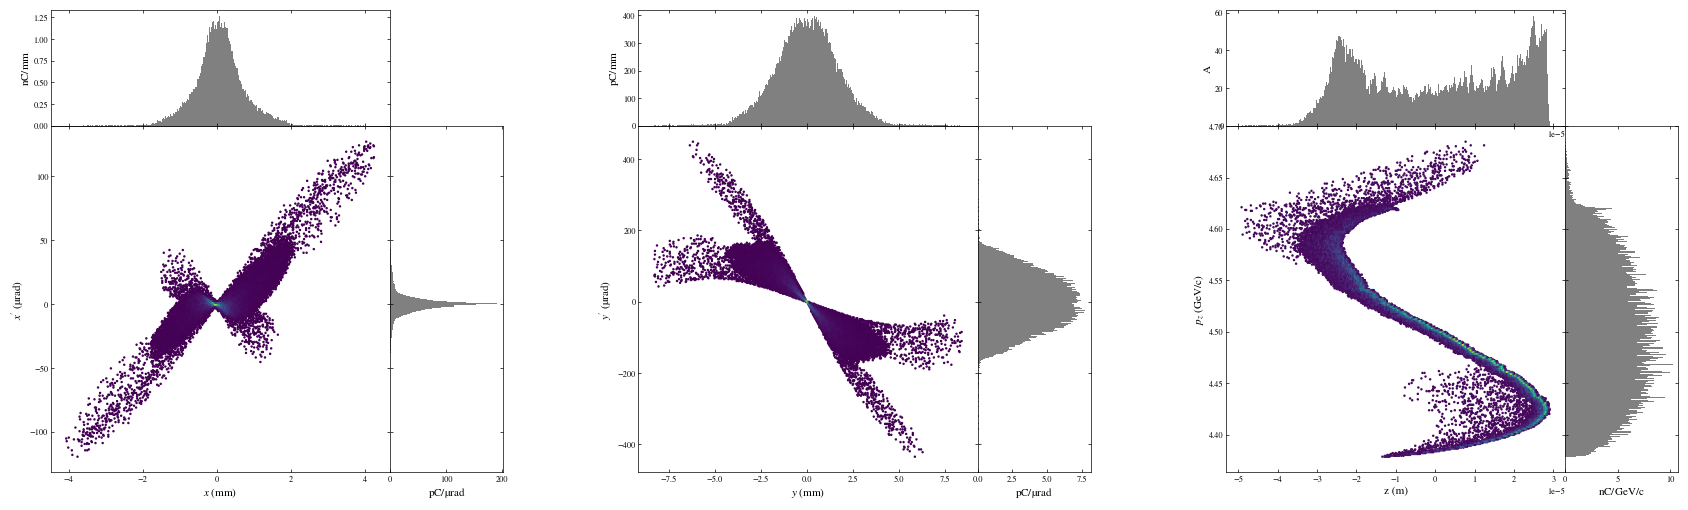

[0.0007282786422911359, 1.5552770294908906e-05, 0.00178107190247344, 8.056337251244115e-05, 0.0, 0.008824921036794066, 6.398099792455446e-14]


In [18]:
tao = kladov.run_initialized_sim(tao, start='L0AFEND', finish='ENDL3F_2')

print(get_energy_at_checkpoints(tao, ["L0AFEND", "L0BFEND", "BC11CBEG", "ENDL2F", "ENDL3F_2"]))
kladov.print_result_from_tao(tao, location="ENDBC14_2", couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], moments=True, sliceEnergyMoment=True, energyInDelta=True, z_from_t=True)

## Beam tweaking

### Scale the external bunch

Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
Overwriting lattice with setLattice()
CSR off, SC off


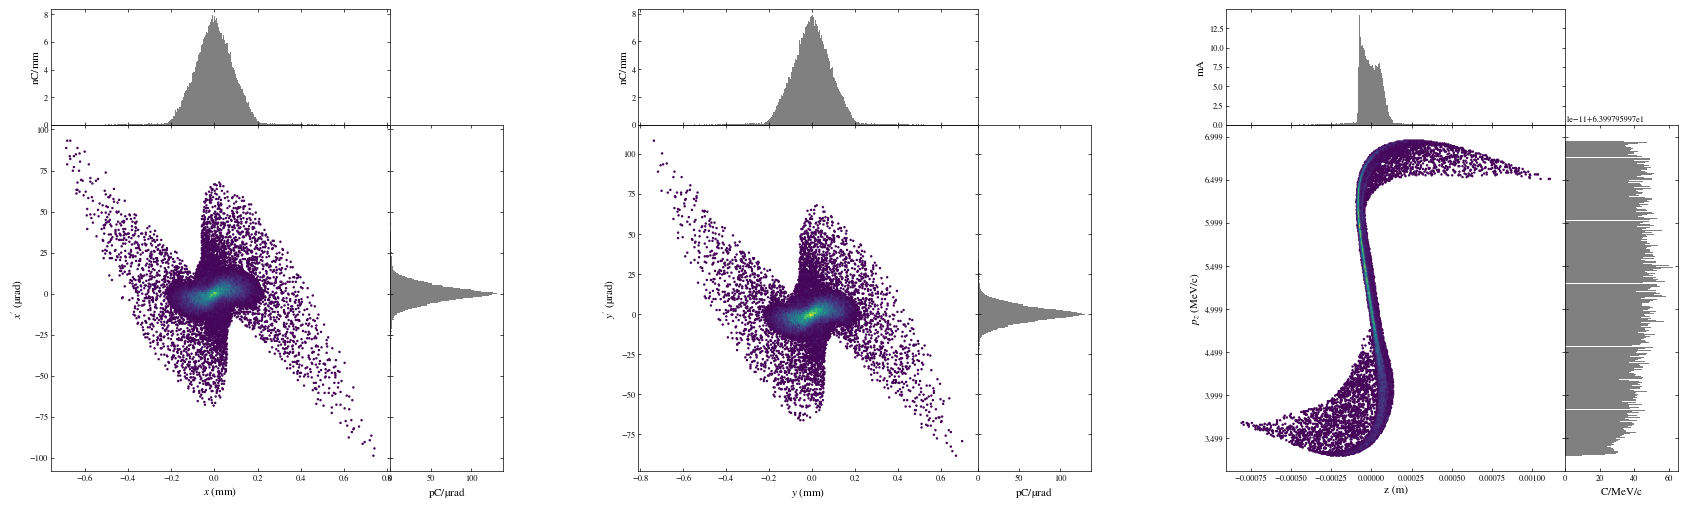

[9.985933773509406e-05, 1.0170786337634823e-05, 0.00010048873324874787, 1.0066850714511146e-05, 0.0, 0.020197990504961107, 3.3910841305037924e-13]


In [19]:
reload_kladov()
tao = kladov.get_tao_from_experiment(filepath=filepath, file_ext = folder + "beams/2024-12-11_Impact_OneBunch/2024-12-11_oneBunch", gaussFromExternal=False, N_to_use_from_file=5e4,
                                    verbose=True, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml", run=False, moments=[1e-4, 1e-5, 1e-4, 1e-5, 1e-4, 1e-5])

kladov.print_result_from_file(folder +"temp_beam/temp_e.h5", couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], z_from_t=True)

### Make a simple Gaussian bunch with the same sizes as the external bunch (\alpha = 0)

Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
Overwriting lattice with setLattice()
CSR off, SC off


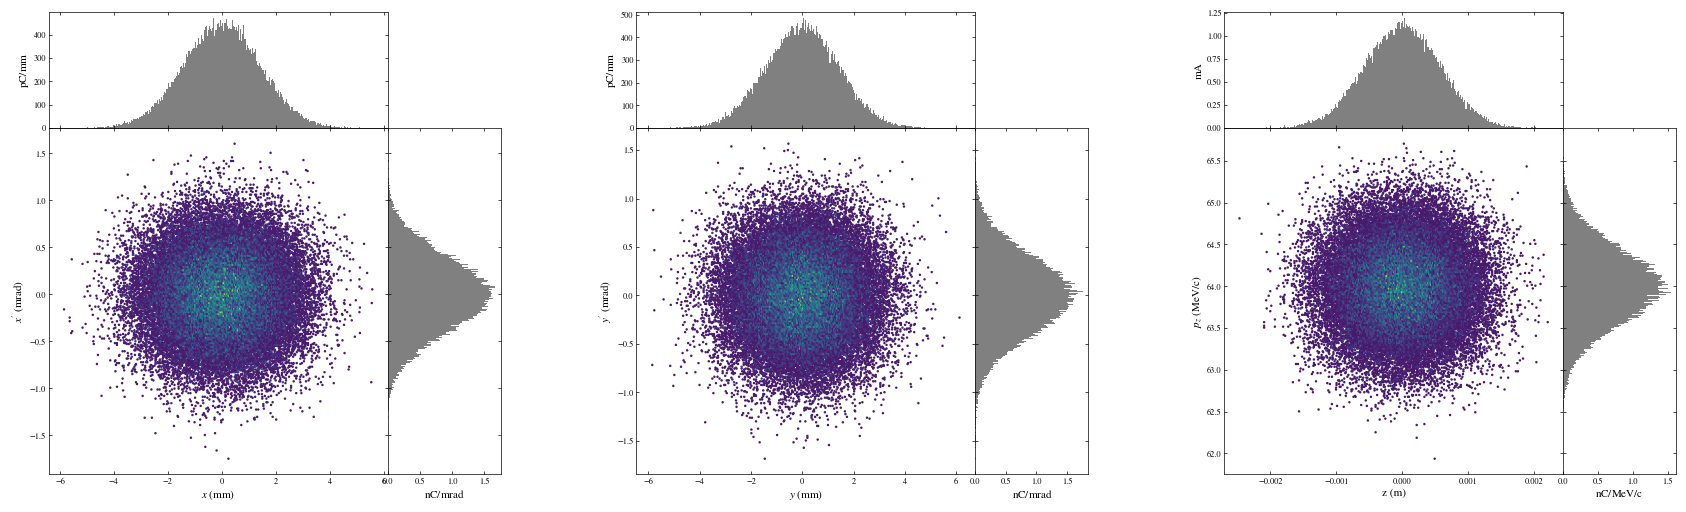

[0.0014260284280795963, 0.0003978083682360569, 0.001426093349329192, 0.00039785941392793346, 0.0, 452288.7534452617, 1.9149571967784075e-12]


In [11]:
reload_kladov()
tao = kladov.get_tao_from_experiment(filepath=filepath, file_ext = folder + "beams/2024-12-11_Impact_OneBunch/2024-12-11_oneBunch", gaussFromExternal=True, N_in_simple_bunch=5e4,
                                    verbose=True, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml", run=False)

kladov.print_result_from_file(folder +"temp_beam/temp_e.h5", couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], z_from_t=True)

### Make a simple bunch using momemnts only

Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
Overwriting lattice with setLattice()
CSR off, SC off


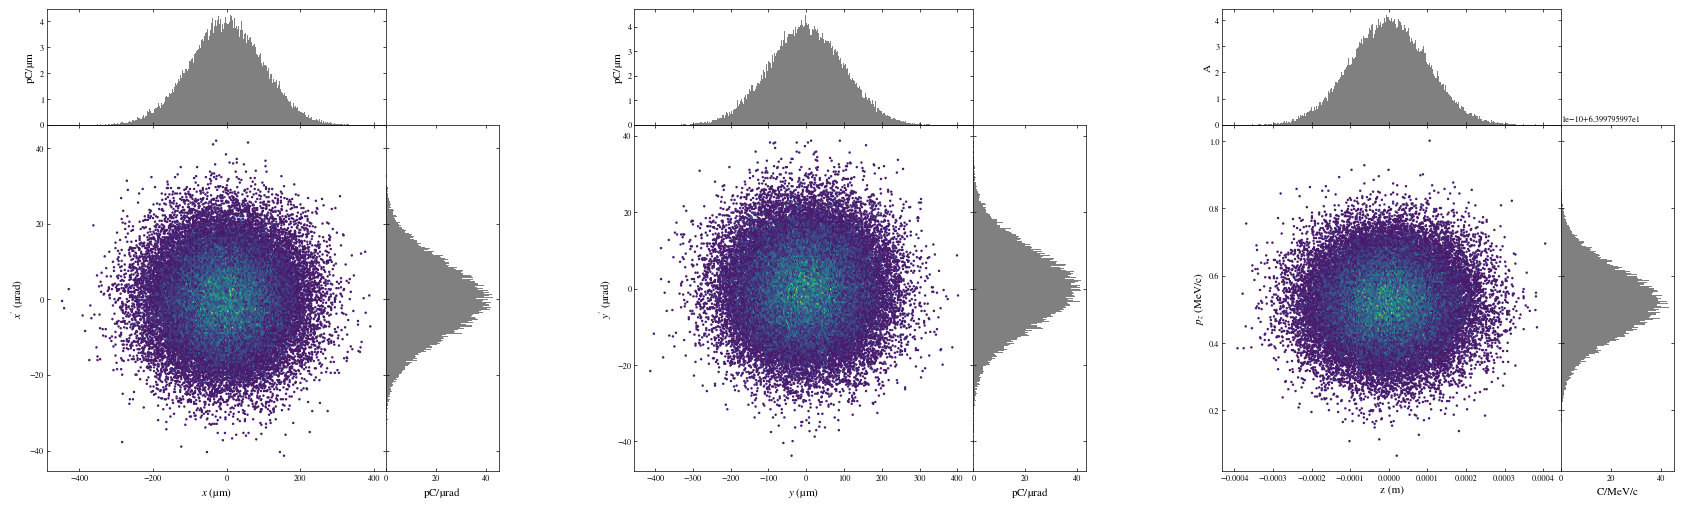

[9.988006595961077e-05, 9.978779593372593e-06, 9.938165087905164e-05, 1.0039428641432863e-05, 0.0, 0.006406958442626971, 3.340499213161664e-13]


In [13]:
reload_kladov()
tao = kladov.get_tao_from_experiment(filepath=filepath, file_ext = "", N_in_simple_bunch=5e4,
                                    verbose=True, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml", run=False, moments=[1e-4, 1e-5, 1e-4, 1e-5, 1e-4, 1e-5])

kladov.print_result_from_file(folder +"temp_beam/temp_e.h5", couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], z_from_t=True)

## Set_beam()

Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
Overwriting lattice with setLattice()
CSR off, SC off


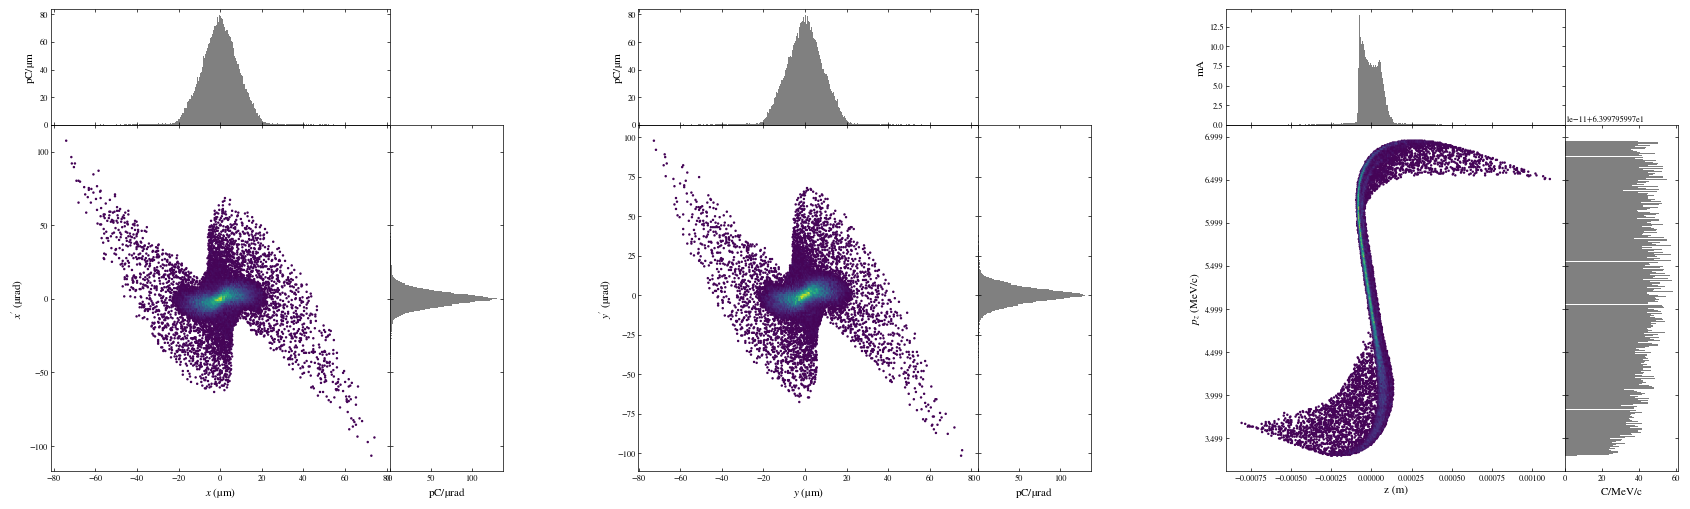

[9.984740254805888e-06, 1.0024708400825356e-05, 9.907257545325085e-06, 1.0031532594240799e-05, 0.0, 0.019822225524685516, 3.344654917250864e-13]


In [11]:
reload_kladov()
tao = kladov.get_tao_from_experiment(filepath=filepath, file_ext = folder + "beams/2024-12-11_Impact_OneBunch/2024-12-11_oneBunch", gaussFromExternal=False, N_in_simple_bunch=5e4,
                                    verbose=True, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml", run=False)

kladov.edit_bunch_parameters(folder + "temp_beam/temp_e", pzMeV=-1, moments=[1e-5, 1e-5, 1e-5, 1e-5, 1e-4, 1e-5], correlations=[None,None,None], means=[0,0,0,0,0], charge=1.6e-9, betaX=None, alphaX=None, emittanceX=-1, betaY=None, alphaY=None, emittanceY=-1, path_to_write=folder + "temp_beam/temp")
kladov.set_beam(tao, folder + "temp_beam/temp", numMacroParticles=5e4)
tao = kladov.run_initialized_sim(tao, start="L0AFEND", finish="L0BFEND")
kladov.print_result_from_tao(tao, location="L0AFEND", couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], moments=True, z_from_t=True)

## SC and CSR

### Base

In [ ]:
# def change_tao_for_csr(tao, locations):
    # elems = kladov.get_element_array(tao, locations[0], locations[-1], values_to_remove=['Marker'], marginl=0, marginr=0)[:,1]
    # for ele in elems:
        # tao.cmd(f"set ele {ele} {'NUM_STEPS'} = {'100'}")

Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
Overwriting lattice with setLattice()
CSR off, SC off


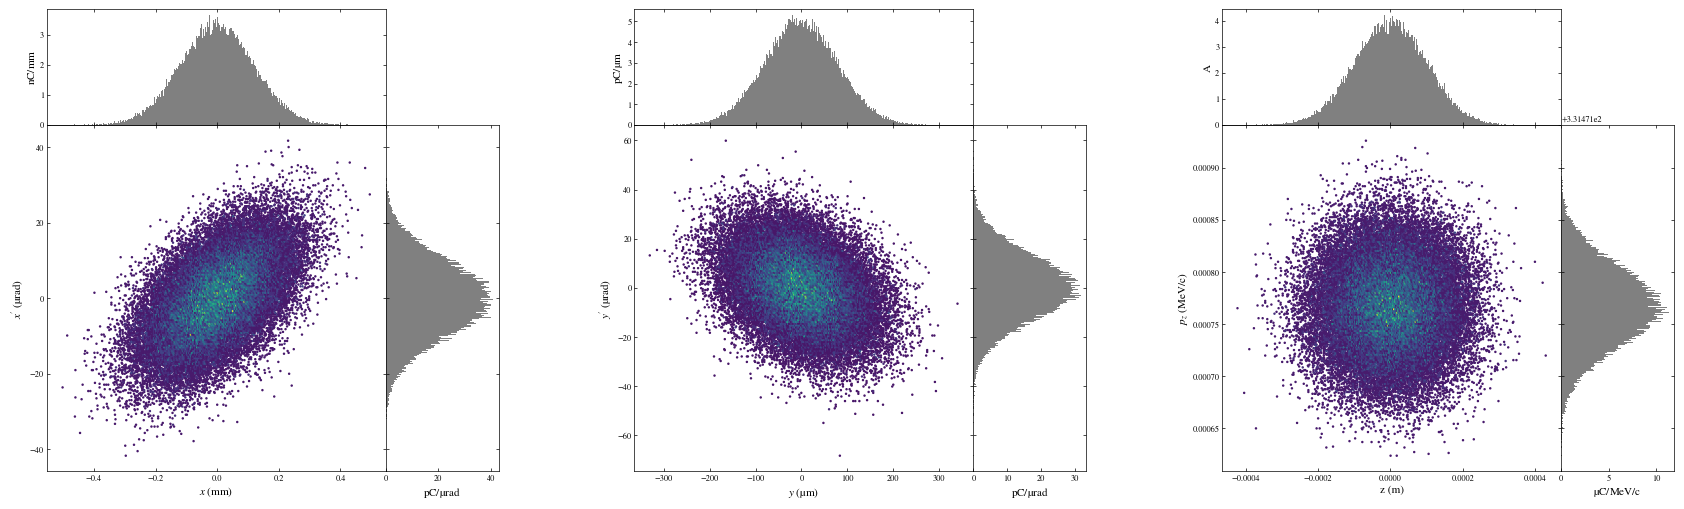

[0.00011985699381633442, 1.0011422988708041e-05, 7.971252240939012e-05, 1.3277745986533e-05, 0.0, 1.1440230729667401e-07, 3.3378617646112317e-13]


In [ ]:
reload_kladov()
start="BC11CBEG"
finish="BC11CEND"
tao = kladov.get_tao_from_experiment(start=start, filepath=filepath, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml", run=False, verbose=True,
                                    N_in_simple_bunch=5e4, moments=[1e-4, 1e-5, 1e-4, 1e-5, 1e-4, 1e-5], charge=1.6e-9,
                                    lscTF=False, csrTF=False, sr_wakes_on=False, lr_wakes_on=False)


elems = kladov.get_element_array(tao, start, finish, values_to_show=['Quadrupole'], marginl=0, marginr=0)[:,1]
for ele in elems:
    tao.cmd(f"set ele {ele} B1_GRADIENT = {0}")

tao = kladov.run_initialized_sim(tao, start=start, finish=finish)
kladov.print_result_from_tao(tao, location=finish, couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], moments=True, sliceEnergyMoment=True, energyInDelta=True, z_from_t=True)

### LSC

Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
Overwriting lattice with setLattice()
CSR off, SC on


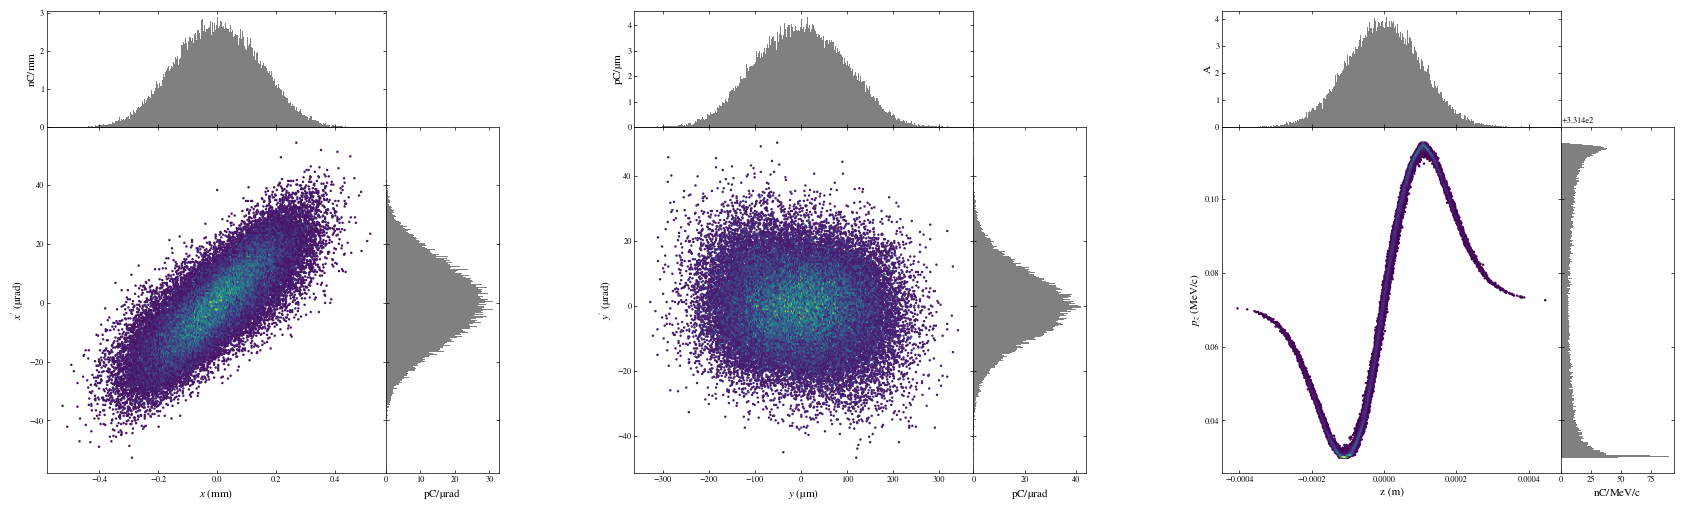

[0.00014119437264184338, 1.3526069712028148e-05, 9.520296798942904e-05, 1.0889496365948032e-05, 0.0, 6.540082197036439e-06, 3.3926789952255187e-13]


In [ ]:
# The longitudinal phase space has a sin() shape.
reload_kladov()
start="BC11CBEG"
finish="BC11CEND"
tao = kladov.get_tao_from_experiment(start=start, filepath=filepath, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml", run=False, verbose=True,
                                    N_in_simple_bunch=5e4, moments=[1e-4, 1e-5, 1e-4, 1e-5, 1e-4, 1e-5], charge=1.6e-9,
                                    lscTF=True, csrTF=False, sr_wakes_on=False, lr_wakes_on=False, lsc_method="slice", csr_method="1_dim", n_bin=32)


elems = kladov.get_element_array(tao, start, finish, values_to_show=['Quadrupole'], marginl=0, marginr=0)[:,1]
for ele in elems:
    tao.cmd(f"set ele {ele} B1_GRADIENT = {0}")

tao = kladov.run_initialized_sim(tao, start=start, finish=finish)
kladov.print_result_from_tao(tao, location=finish, couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], moments=True, sliceEnergyMoment=True, energyInDelta=True, z_from_t=True)

### CSR

Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
Overwriting lattice with setLattice()
CSR on, SC off


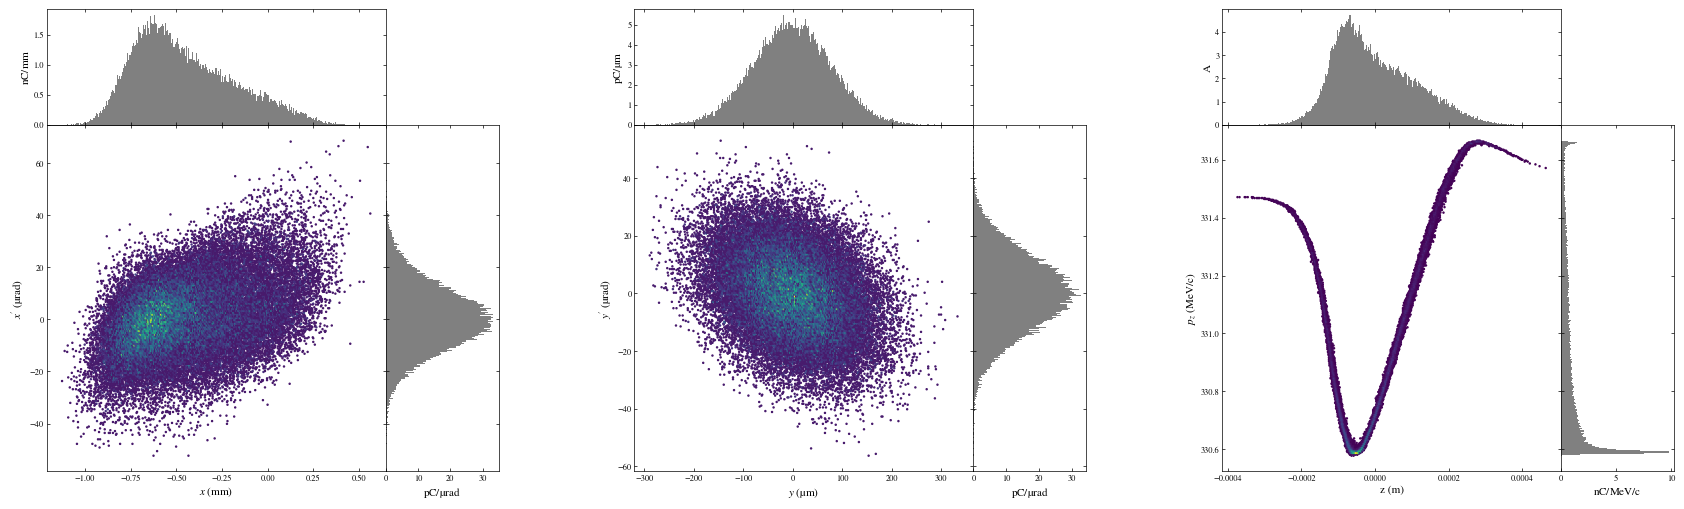

[0.0002738511545618194, 1.311801186570316e-05, 7.955220757820632e-05, 1.3254569006163766e-05, 0.0, 2.9602071419691306e-05, 3.6686553956451854e-13]


In [ ]:
# The longitudinal phase space has an asymmetric V shape.
reload_kladov()
start="BC11CBEG"
finish="BC11CEND"
tao = kladov.get_tao_from_experiment(start=start, filepath=filepath, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml", run=False, verbose=True,
                                    N_in_simple_bunch=5e4, moments=[1e-4, 1e-5, 1e-4, 1e-5, 1e-4, 1e-5], charge=1.6e-9,
                                    lscTF=False, csrTF=True, sr_wakes_on=False, lr_wakes_on=False, lsc_method="slice", csr_method="1_dim", n_bin=32)


elems = kladov.get_element_array(tao, start, finish, values_to_show=['Quadrupole'], marginl=0, marginr=0)[:,1]
for ele in elems:
    tao.cmd(f"set ele {ele} B1_GRADIENT = {0}")

tao = kladov.run_initialized_sim(tao, start=start, finish=finish)
kladov.print_result_from_tao(tao, location=finish, couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], moments=True, sliceEnergyMoment=True, energyInDelta=True, z_from_t=True)

### Together

Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
Overwriting lattice with setLattice()
CSR on, SC on


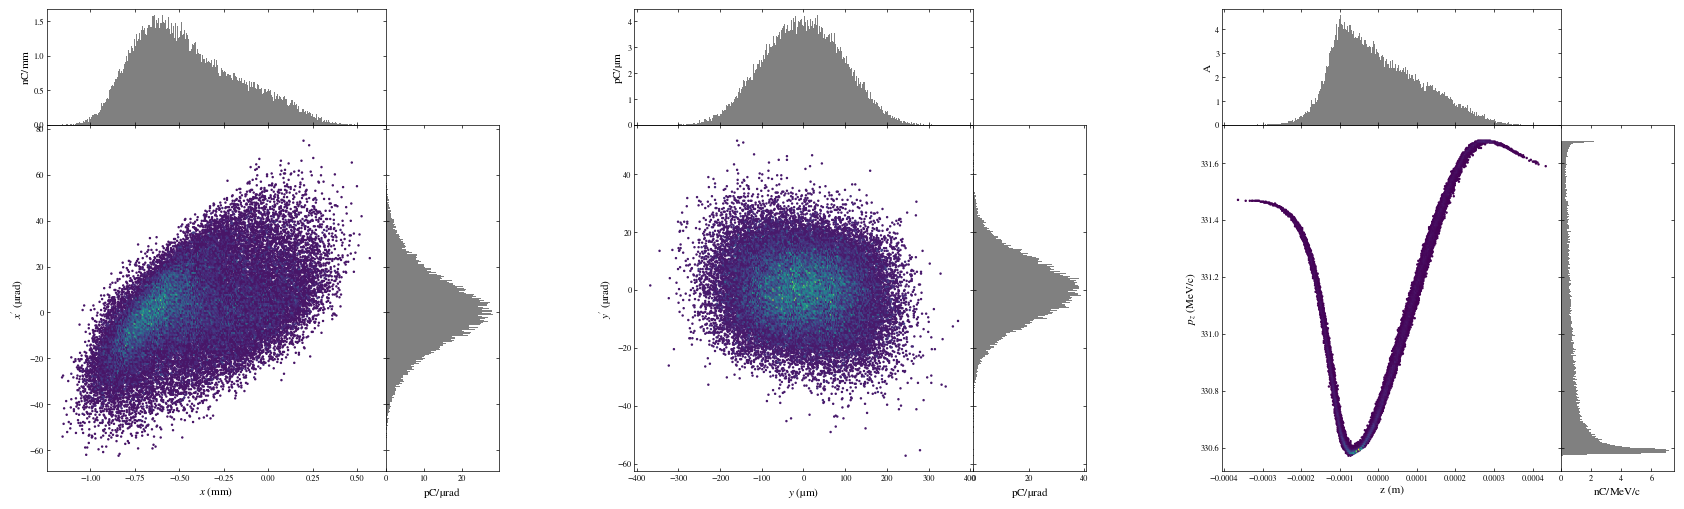

[0.0002909450249963067, 1.659550559877892e-05, 9.47156097613055e-05, 1.0892871948864493e-05, 0.0, 4.9727356978890106e-05, 3.7395265782992674e-13]


In [ ]:
# If tracked together, the CSR has a larger effect (in a chicane).
reload_kladov()
start="BC11CBEG"
finish="BC11CEND"
tao = kladov.get_tao_from_experiment(start=start, filepath=filepath, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml", run=False, verbose=True,
                                    N_in_simple_bunch=5e4, moments=[1e-4, 1e-5, 1e-4, 1e-5, 1e-4, 1e-5], charge=1.6e-9,
                                    lscTF=True, csrTF=True, sr_wakes_on=False, lr_wakes_on=False, lsc_method="slice", csr_method="1_dim", n_bin=32)


elems = kladov.get_element_array(tao, start, finish, values_to_show=['Quadrupole'], marginl=0, marginr=0)[:,1]
for ele in elems:
    tao.cmd(f"set ele {ele} B1_GRADIENT = {0}")

tao = kladov.run_initialized_sim(tao, start=start, finish=finish)
kladov.print_result_from_tao(tao, location=finish, couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], moments=True, sliceEnergyMoment=True, energyInDelta=True, z_from_t=True)

## Lattice change (from a file)

Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
CSR off, SC off


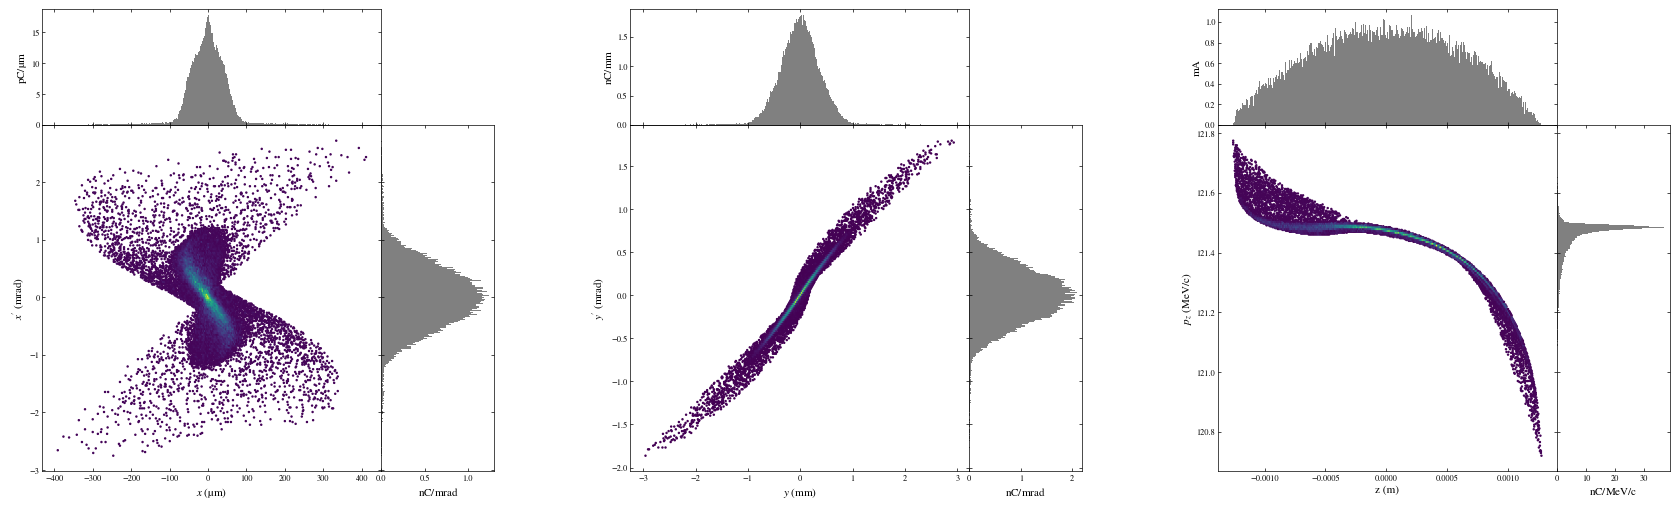

[5.639011215630033e-05, 0.000557922574534196, 0.00041869564276209373, 0.0003389665817717337, 0.0, 97069.55669104584, 1.9274545657016103e-12]


In [4]:
reload_kladov()
tao = kladov.get_tao_from_experiment(start='L0AFEND', finish='L0BFEND', filepath=filepath, file_ext = folder + "beams/2024-12-11_Impact_OneBunch/2024-12-11_oneBunch",
                                     N_to_use_from_file=5e4, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml")

kladov.print_result_from_tao(tao, location="L0BFEND", couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], z_from_t=True)

Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
CSR off, SC off


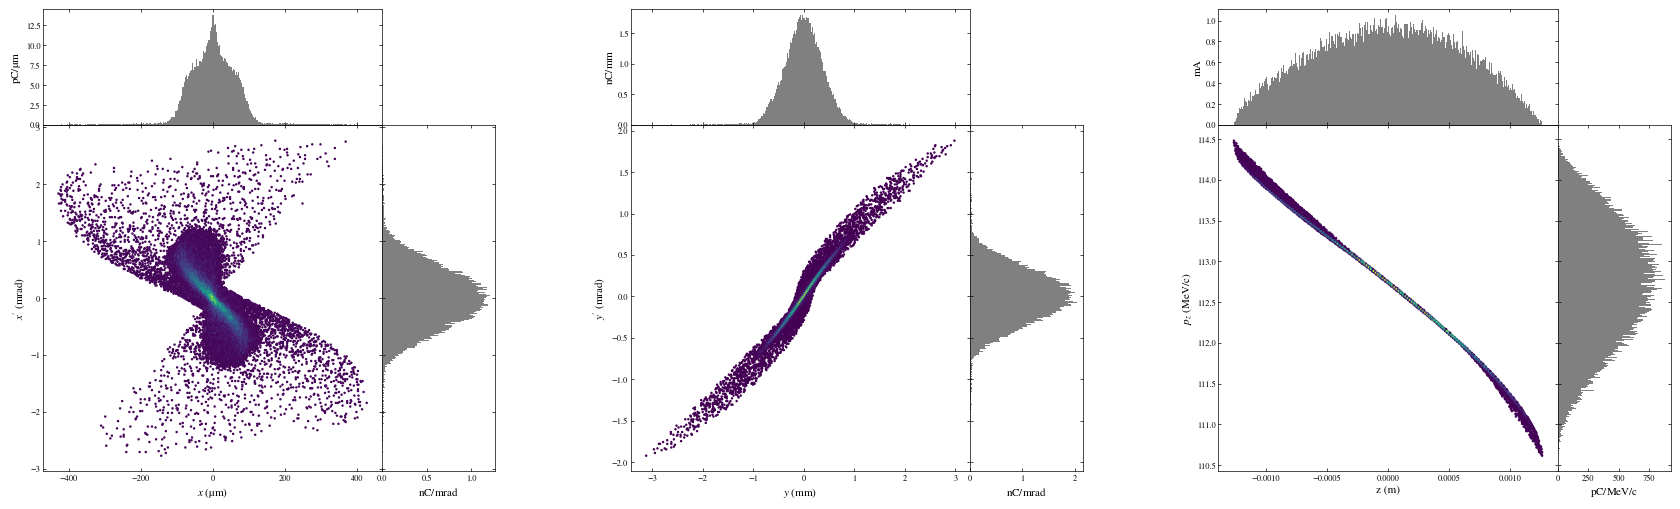

[7.210622818026199e-05, 0.0005653318775319205, 0.0004267526850886763, 0.0003480799332609197, 0.0, 725529.2558739975, 1.921515642071469e-12]


In [5]:
reload_kladov()
tao = kladov.get_tao_from_experiment(start='L0AFEND', finish='L0BFEND', filepath=filepath, file_ext = folder + "beams/2024-12-11_Impact_OneBunch/2024-12-11_oneBunch",
                                     N_to_use_from_file=5e4, lattice="setLattice_configs/2024-10-22_oneBunch-Copy2.yml")

kladov.print_result_from_tao(tao, location="L0BFEND", couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], z_from_t=True)

# General bunch edit function

### Create a Gaussian bunch

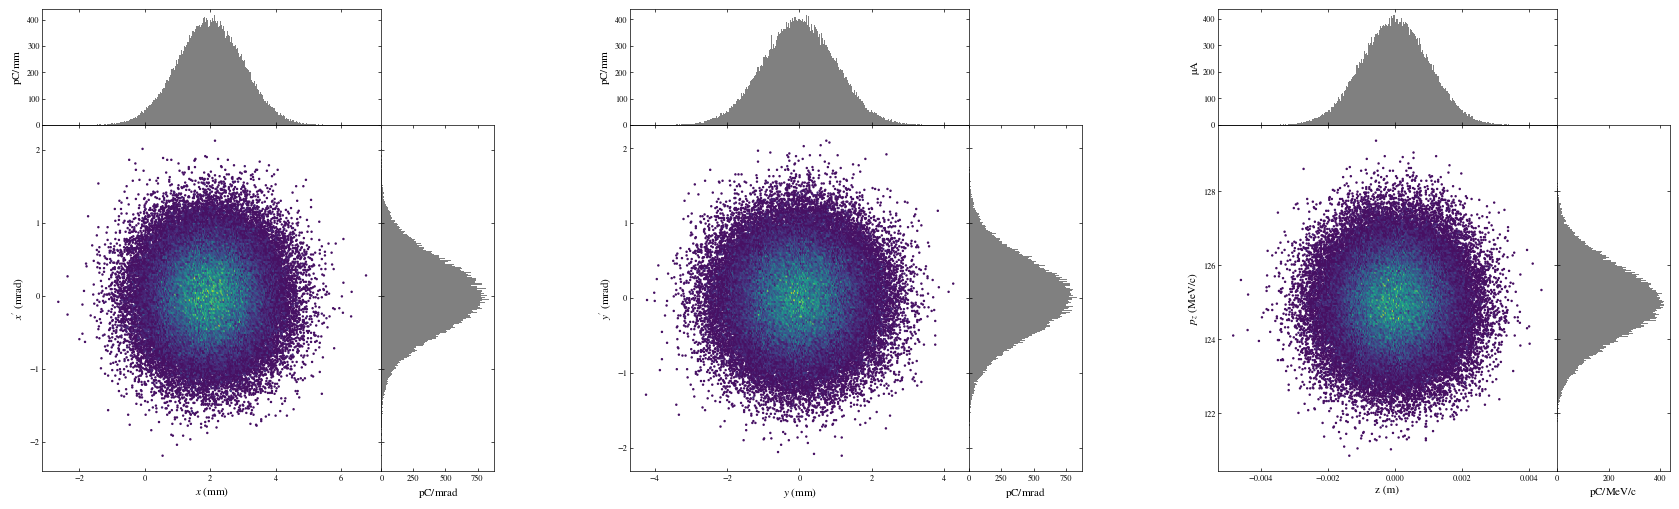

[0.00099984820799692, 0.0004993447326166905, 0.0009995862913032866, 0.0004980929918886674, 0.0, 994248.7151797741, 3.3448784500696198e-12]


In [47]:
reload_kladov()
tempP = kladov.make_simple_bunch_standalone(N=1e5, meanPzMeV=125, moments=[1e-3, 0.5e-3, 1e-3, 0.5e-3, 1e-3, 1e6], save_path = folder + 'temp_beam/temp', means=[2e-3,0,0,0,0,0])
kladov.print_result(tempP, couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], moments=True, energyInDelta=False, z_from_t=True)

### Verify that the default settings preserve the bunch

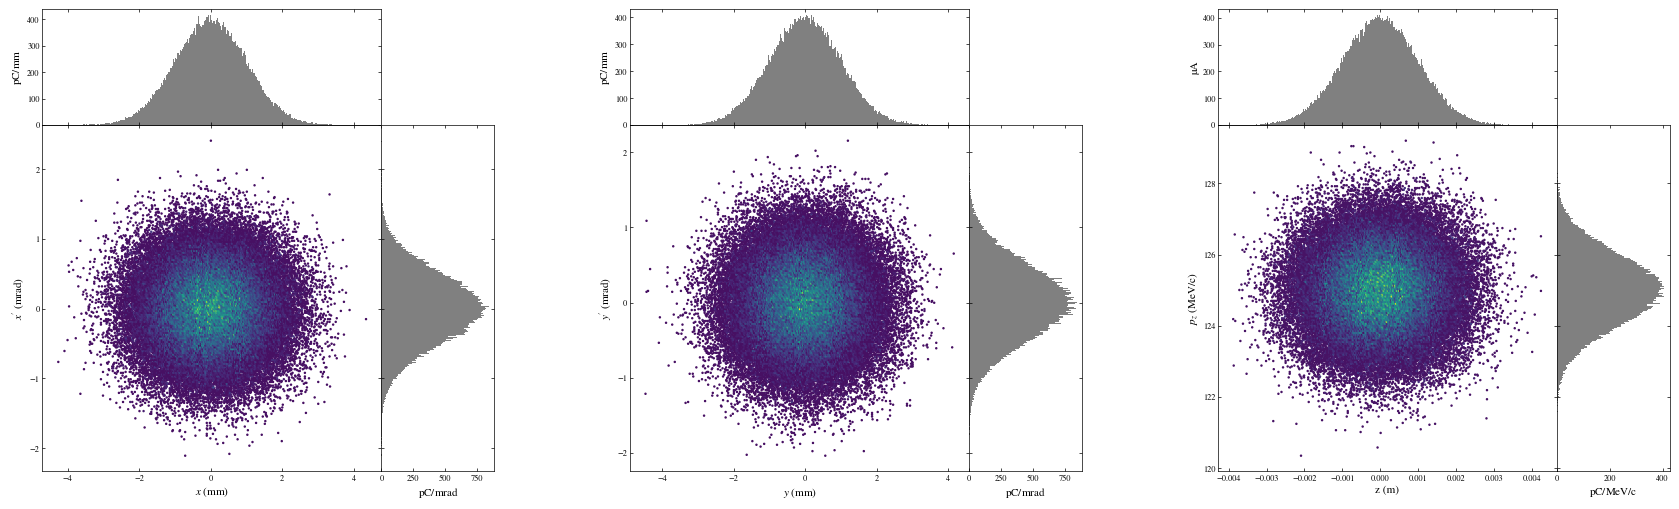

[0.0010013393469871126, 0.0005009447924159953, 0.0010015658497625575, 0.0005011596665799627, 0.0, 1003115.5568879895, 3.3308067272101823e-12]


In [27]:
tempP1 = kladov.edit_bunch_parameters_from_PG(tempP, path_to_write=folder+'temp_beam/temp')
kladov.print_result(tempP1, couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], moments=True, energyInDelta=False, z_from_t=True)

### Edits with "moments" and "correlations" + mean shift. Note that "None" 'yp' moment resulted in a different 'yp' moment from before - because "None" preserves 'py' (in eV)

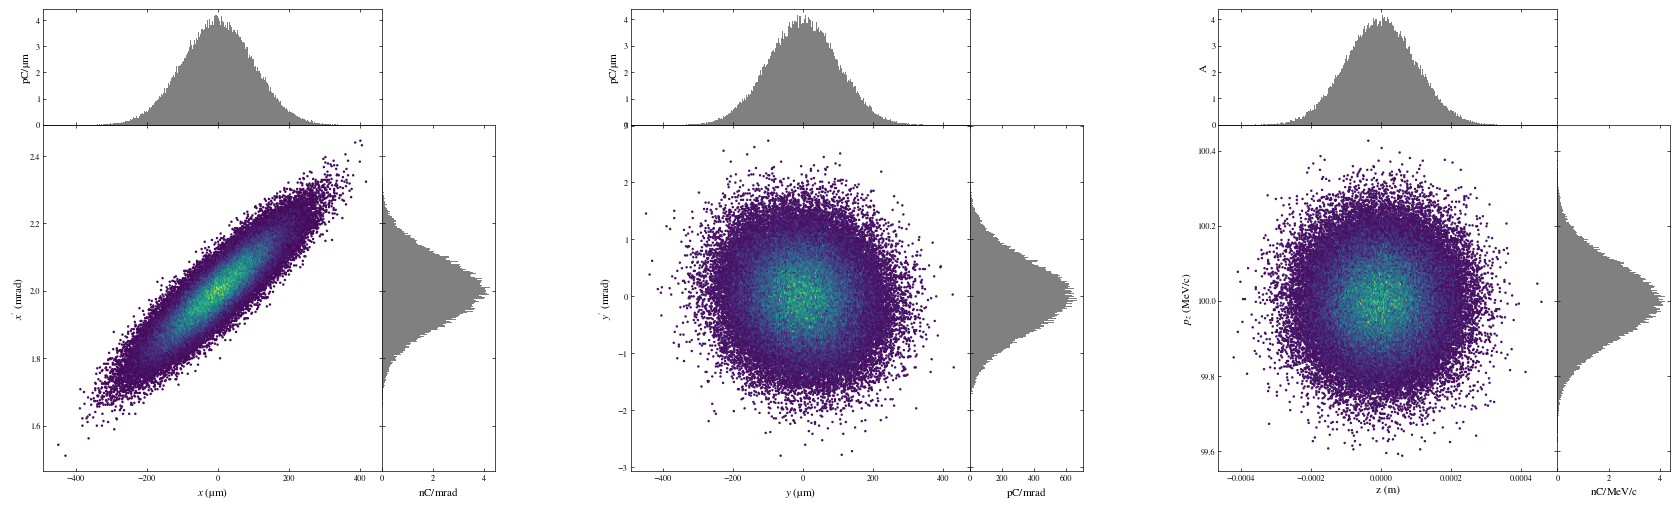

[0.0001, 0.00010002246158904039, 0.00010000000000000007, 0.0006252783561727234, 0.0, 99998.52797673718, 3.3333333333333334e-13]


In [ ]:
tempP1 = kladov.edit_bunch_parameters_from_PG(tempP, pzMeV=100, moments=[1e-4, 1e-4, 1e-4, None, 1e-4, 1e5], correlations=[0.9,-0.1,None], means=[0,2e-3,0,0,0],
                                  charge=-1, betaX=None, alphaX=None, emittanceX=None, betaY=None, alphaY=None, emittanceY=None, path_to_write=folder+'temp_beam/temp')
kladov.print_result(tempP1, couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], moments=True, energyInDelta=False, z_from_t=True)

### Edits with beta, alpha and emittance. Note that the planes are treated separately (the Y PS is changed according to the "moments" in the example below)

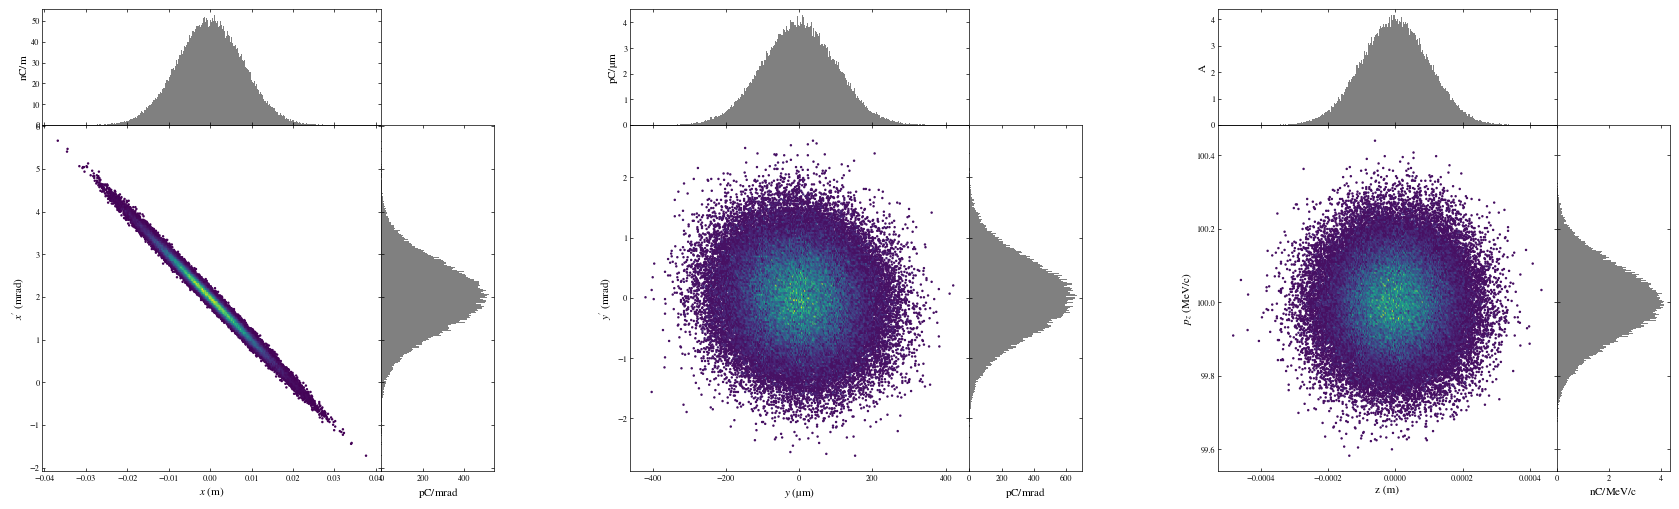

[0.007899235098894675, 0.0007938584535092241, 9.99999999999999e-05, 0.0006225379572071779, 0.0, 99999.16920137475, 3.3333333333333334e-13]


In [48]:
tempP1 = kladov.edit_bunch_parameters_from_PG(tempP, pzMeV=100, moments=[1e-4, 1e-4, 1e-4, None, 1e-4, 1e5], correlations=[0.9,-0.1,None], means=[0,2e-3,0,0,0],
                                  charge=-1, betaX=100, alphaX=10, emittanceX=None, betaY=None, alphaY=None, emittanceY=None, path_to_write=folder+'temp_beam/temp')
kladov.print_result(tempP1, couples=[['x', 'xp'],['y', 'yp'],['z', 'pz']], moments=True, energyInDelta=False, z_from_t=True)

# Get the lattice info

## List elements

In [10]:
reload_kladov()
tao = kladov.initializeTao(filePath = filepath, latticeFile = "setLattice_configs/2024-10-22_oneBunch-Copy1.yml", verbose=False)

kladov.get_element_array(tao, "BX0FBEG", "BX0FEND", values_to_show=["Marker", "Quadrupole", "Bend"], values_to_remove=[], marginl=0, marginr=0)

array([['16.750287621821375', 'BX0FBEG', 'Marker'],
       ['17.73407962382505', 'QB10731#1', 'Quadrupole'],
       ['17.78747962382505', 'QB10731#2', 'Quadrupole'],
       ['18.717871625828725', 'CNT0F', 'Marker'],
       ['18.717871625828725', 'BX0FEND', 'Marker']], dtype='<U32')

## Get the general simulation parameters

In [4]:
tao.show("global")
#tao.show("space_charge_com")
#tao.show("ptc_com")

['Tao Global parameters [Note: To print optimizer globals use: "show optimizer"]',
 '  %beam_timer_on                 = T',
 '  %bunch_to_plot                 = 1',
 '  %datum_err_messages_max        = 10',
 '  %cmd_file_abort_on_error       = T',
 '  %concatenate_maps              = F',
 '  %beam_dead_cutoff              =   9.90000010E-01',
 '  %delta_e_chrom                 =   1.00000000E-04',
 '  %disable_smooth_line_calc      = F',
 '  %draw_curve_off_scale_warn     = T',
 '  %init_lat_sigma_from_beam      = F',
 '  %label_lattice_elements        = T',
 '  %label_keys                    = T',
 '  %lattice_calc_on               = T',
 '  %max_plot_time                 =   5.00000000E+00',
 '  %n_threads                     = 7',
 '  %only_limit_opt_vars           = F',
 '  %opt_match_auto_recalc         = F',
 '  %opti_write_var_file           = T',
 '  %optimizer_var_limit_warn      = T',
 '  %phase_units                   = radians',
 '  %rad_int_calc_on               = T',
 '  

## Get the map terms

In [ ]:
reload_kladov()
tao = kladov.initializeTao(filePath = filepath, latticeFile = "setLattice_configs/2024-10-22_oneBunch-Copy1.yml", verbose=False)

print([float(kladov.get_rij(tao, "BX0FBEG", "BX0FEND", 5, j+1)) for j in range(6)])
print([float(kladov.get_rij(tao, "BX0FBEG", "BX0FEND", i+1, 6)) for i in range(6)])

print([float(kladov.get_tijk(tao, "BX0FBEG", "BX0FEND", 5, j+1, j+1)) for j in range(6)])
print([float(kladov.get_tijk(tao, "BX0FBEG", "BX0FEND", i+1, 6, 6)) for i in range(6)])

[-0.0, -0.0, 0.0, 0.0, 1.0, -0.00627907]
[0.0, 0.0, 0.0, 0.0, -0.00627907, 1.0]
[-2.56514368267668, -1.17474352706807, -1.65727930845136, -8.7002407902865, 0.0, -0.22978302608172]
[-0.576081233976983, -0.586766518575408, 0.0, 0.0, -0.22978302608172, 1.55431223447522e-15]


# Scan functions

## Scanning the map terms (Easy)

In [ ]:
reload_kladov()

def adjust_tao_for_a_sextupole_scan(tao, value, sx_to_scan=0, sextupoleStrengths=[1500,0,0,0,0,0], sextupoleXOffsets=[0,0,0,0,0,0], sextupoleYOffsets=[0,0,0,0,0,0], **kwargs):
    sextupoleXOffsets[sx_to_scan] = value
    tao = kladov.setAllWChicaneSextupoles(tao, sextupoleStrengths[0],sextupoleStrengths[1],sextupoleStrengths[2],sextupoleStrengths[3],sextupoleStrengths[4],sextupoleStrengths[5])
    tao = kladov.setAllWChicaneSextupolesXOffsets(tao, sextupoleXOffsets[0], sextupoleXOffsets[1], sextupoleXOffsets[2], sextupoleXOffsets[3], sextupoleXOffsets[4], sextupoleXOffsets[5])
    tao = kladov.setAllWChicaneSextupolesYOffsets(tao, sextupoleYOffsets[0], sextupoleYOffsets[1], sextupoleYOffsets[2], sextupoleYOffsets[3], sextupoleYOffsets[4], sextupoleYOffsets[5])
    return tao

def get_terms_in_a_sextupole_scan(tao, term_i=5, term_j=1, term_k=None, start='ENDBC14_2', finish='PENT', **kwargs):
    return kladov.get_rij(tao, start, finish, term_i, term_j) if term_k is None else kladov.get_tijk(tao, start, finish, term_i, term_j, term_k)
    
# ------------------------------------------------------------
# 1D scan of sextupole position and returning a term (R or T)
def get_terms_dep_on_sx_position(tao, term_i=5, term_j=1, term_k=None, start='ENDBC14_2', finish='PENT', mean=0, nscan=21, scan_span=5e-3,
                sx_to_scan=0, sextupoleStrengths=[1500,0,0,0,0,0], sextupoleXOffsets=[0,0,0,0,0,0], sextupoleYOffsets=[0,0,0,0,0,0], plot=True):
    ylabel = f'R_({term_i},{term_j})' if term_k is None else f'T_({term_i},{term_j},{term_k})'
    scan_values, output = kladov.make_1d_scan(tao, mean=mean, nscan=nscan, scan_span=scan_span, plot=plot,
                 function_to_change_tao_in_scan = adjust_tao_for_a_sextupole_scan,
                 function_to_get_results_in_scan = get_terms_in_a_sextupole_scan,
                 label=ylabel, ylabel=ylabel, xlabel=f'{sx_to_scan} sextupole X offset (m)',
                term_i=term_i, term_j=term_j, term_k=term_k, start=start, finish=finish,
                sx_to_scan=sx_to_scan, sextupoleStrengths=sextupoleStrengths, sextupoleXOffsets=sextupoleXOffsets, sextupoleYOffsets=sextupoleYOffsets)
    return scan_values, output

PR11375


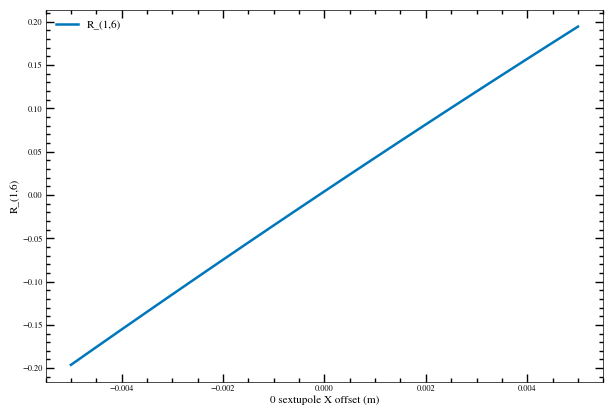

In [41]:
mean=0
nscan=21
scan_span=1e-2
sx_to_scan=0
sextupoleStrengths=[1500,0,0,0,0,0]
sextupoleXOffsets=[0,0,0,0,0,0]
sextupoleYOffsets=[0,0,0,0,0,0]

reload_kladov()
experiment="BEAMPHYS"
scan_number="14438"
date="/2026/20260121"
tao = kladov.get_tao_from_experiment(experiment=experiment, scan_number=scan_number, date=date, run=False, filepath=filepath)

values, terms = get_terms_dep_on_sx_position(tao, term_i=1, term_j=6, term_k=None, start='BEGBC20', finish='DTOTR', mean=mean, nscan=nscan, scan_span=scan_span,
                sx_to_scan=sx_to_scan, sextupoleStrengths=sextupoleStrengths, sextupoleXOffsets=sextupoleXOffsets, sextupoleYOffsets=sextupoleYOffsets)

PR11375


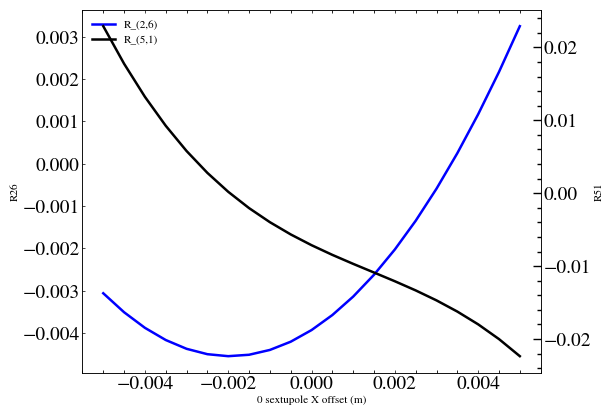

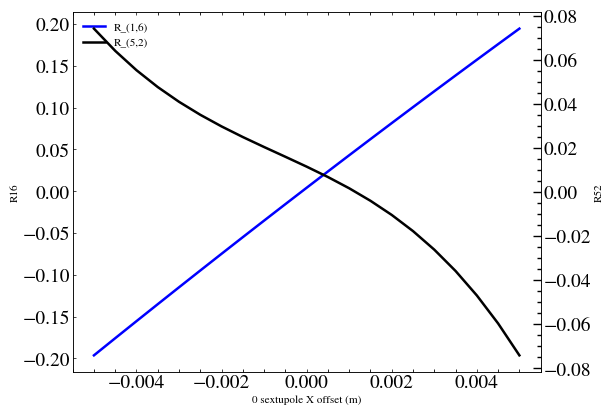

In [44]:
mean=0
nscan=21
scan_span=1e-2
sx_to_scan=0
sextupoleStrengths=[1500,0,0,0,0,0]
sextupoleXOffsets=[0,0,0,0,0,0]
sextupoleYOffsets=[0,0,0,0,0,0]

reload_kladov()
experiment="BEAMPHYS"
scan_number="14438"
date="/2026/20260121"
tao = kladov.get_tao_from_experiment(experiment=experiment, scan_number=scan_number, date=date, run=False, filepath=filepath)

values, terms = get_terms_dep_on_sx_position(tao, term_i=2, term_j=6, term_k=None, start='BEGBC20', finish='DTOTR', mean=mean, nscan=nscan, scan_span=scan_span,
                sx_to_scan=sx_to_scan, sextupoleStrengths=sextupoleStrengths, sextupoleXOffsets=sextupoleXOffsets, sextupoleYOffsets=sextupoleYOffsets, plot=False)

values, terms1 = get_terms_dep_on_sx_position(tao, term_i=5, term_j=1, term_k=None, start='BEGBC20', finish='DTOTR', mean=mean, nscan=nscan, scan_span=scan_span,
                sx_to_scan=sx_to_scan, sextupoleStrengths=sextupoleStrengths, sextupoleXOffsets=sextupoleXOffsets, sextupoleYOffsets=sextupoleYOffsets, plot=False)

kladov.make_a_plot([values, values], [terms, terms1], x_label=f'{sx_to_scan} sextupole X offset (m)', y_label=['R26', 'R51'], label=['R_({},{})'.format(2,6), 'R_({},{})'.format(5,1)], cartesian_axes=[False, False])

values, terms = get_terms_dep_on_sx_position(tao, term_i=1, term_j=6, term_k=None, start='BEGBC20', finish='DTOTR', mean=mean, nscan=nscan, scan_span=scan_span,
                sx_to_scan=sx_to_scan, sextupoleStrengths=sextupoleStrengths, sextupoleXOffsets=sextupoleXOffsets, sextupoleYOffsets=sextupoleYOffsets, plot=False)

values, terms1 = get_terms_dep_on_sx_position(tao, term_i=5, term_j=2, term_k=None, start='BEGBC20', finish='DTOTR', mean=mean, nscan=nscan, scan_span=scan_span,
                sx_to_scan=sx_to_scan, sextupoleStrengths=sextupoleStrengths, sextupoleXOffsets=sextupoleXOffsets, sextupoleYOffsets=sextupoleYOffsets, plot=False)

kladov.make_a_plot([values, values], [terms, terms1], x_label=f'{sx_to_scan} sextupole X offset (m)', y_label=['R16', 'R52'], label=['R_({},{})'.format(1,6), 'R_({},{})'.format(5,2)], cartesian_axes=[False, False])

## Scanning with tao evaluation (+ using map transformation)

In [5]:
reload_kladov()

def adjust_tao_for_a_sextupole_scan(tao, value, sx_to_scan=0, sextupoleStrengths=[1500,0,0,0,0,0], sextupoleXOffsets=[0,0,0,0,0,0], sextupoleYOffsets=[0,0,0,0,0,0], **kwargs):
    sextupoleXOffsets[sx_to_scan] = value
    tao = kladov.setAllWChicaneSextupoles(tao, sextupoleStrengths[0],sextupoleStrengths[1],sextupoleStrengths[2],sextupoleStrengths[3],sextupoleStrengths[4],sextupoleStrengths[5])
    tao = kladov.setAllWChicaneSextupolesXOffsets(tao, sextupoleXOffsets[0], sextupoleXOffsets[1], sextupoleXOffsets[2], sextupoleXOffsets[3], sextupoleXOffsets[4], sextupoleXOffsets[5])
    tao = kladov.setAllWChicaneSextupolesYOffsets(tao, sextupoleYOffsets[0], sextupoleYOffsets[1], sextupoleYOffsets[2], sextupoleYOffsets[3], sextupoleYOffsets[4], sextupoleYOffsets[5])
    return tao

def get_2nd_order_comparison_dep_on_sx_position(tao, beam_file='temp_beam/temp', start='ENDBC14_2', finish='PENT', mean=0, nscan=21, scan_span=5e-3,
                sx_to_scan=0, sextupoleStrengths=[1500,0,0,0,0,0], sextupoleXOffsets=[0,0,0,0,0,0], sextupoleYOffsets=[0,0,0,0,0,0], verbose=True, plot=False): 
    ylabel = f'induced spread'
    scan_values, output = kladov.make_1d_scan(tao, mean=mean, nscan=nscan, scan_span=scan_span, plot=plot,
                 function_to_change_tao_in_scan = adjust_tao_for_a_sextupole_scan,
                 function_to_get_results_in_scan = kladov.make_comparison_dz_2nd_order,
                 label=ylabel, ylabel=ylabel, xlabel=f'{sx_to_scan} sextupole X offset (m)', start=start, finish=finish,
                 beam_file=beam_file, sx_to_scan=sx_to_scan, sextupoleStrengths=sextupoleStrengths, sextupoleXOffsets=sextupoleXOffsets, sextupoleYOffsets=sextupoleYOffsets)
    output = np.array(output)
    sizes_sim = output[:, 0]
    sizes_theory = output[:, 1]
    if verbose:
        kladov.make_a_plot([scan_values, scan_values], [sizes_sim, sizes_theory], aspect_ratio=0.67, label=[r"Sim", r"Theory"],
                    x_label=f'{sx_to_scan} sextupole X offset (m)', y_label=r"$\sigma_{z,\text{ind}}$ (m)", cartesian_axes=[False, False])
    return scan_values, output

PR11375


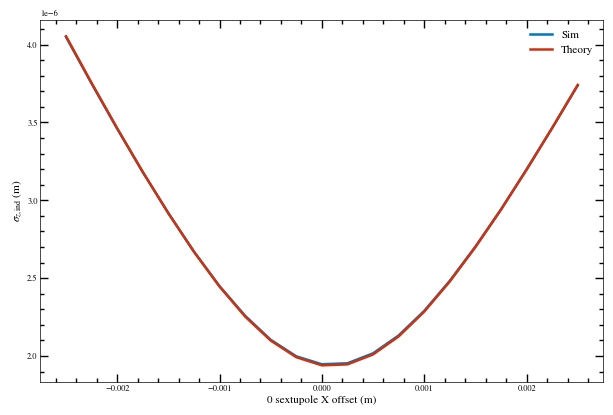

(array([-0.0025 , -0.00225, -0.002  , -0.00175, -0.0015 , -0.00125,
        -0.001  , -0.00075, -0.0005 , -0.00025,  0.     ,  0.00025,
         0.0005 ,  0.00075,  0.001  ,  0.00125,  0.0015 ,  0.00175,
         0.002  ,  0.00225,  0.0025 ]),
 array([[4.04966560e-06, 4.05378566e-06],
        [3.75010911e-06, 3.75357697e-06],
        [3.46006919e-06, 3.46231757e-06],
        [3.18120118e-06, 3.18233178e-06],
        [2.91782214e-06, 2.91670131e-06],
        [2.67065413e-06, 2.66950784e-06],
        [2.44867495e-06, 2.44609546e-06],
        [2.25841951e-06, 2.25324944e-06],
        [2.10395292e-06, 2.09905875e-06],
        [1.99788282e-06, 1.99211837e-06],
        [1.94686190e-06, 1.93981399e-06],
        [1.95330722e-06, 1.94608330e-06],
        [2.01722176e-06, 2.00989131e-06],
        [2.13181763e-06, 2.12557567e-06],
        [2.28975330e-06, 2.28479083e-06],
        [2.48324226e-06, 2.47869813e-06],
        [2.70255545e-06, 2.69938338e-06],
        [2.94115293e-06, 2.94039062e-06],


In [9]:
reload_kladov()
experiment="BEAMPHYS"
scan_number="14438"
date="/2026/20260121"
tao = kladov.get_tao_from_experiment(experiment=experiment, scan_number=scan_number, date=date, filepath=filepath, start='BEGBC20',
                                     finish='ENDBC20', run=False, moments=[1e-4,1e-4,1e-4,1e-4,0,0])
mean=0
nscan=21
scan_span=5e-3
sx_to_scan=0
sextupoleStrengths=[1500,0,0,0,0,0]
sextupoleXOffsets=[0,0,0,0,0,0]
sextupoleYOffsets=[0,0,0,0,0,0]

elements = kladov.get_element_array(tao, "BEGBC20", "ENDBC20", values_to_show=['Quadrupole'], marginl=0, marginr=0)[:,1]
for ele in elements:
    tao.cmd(f"set ele {ele} B1_GRADIENT = {0}")

get_2nd_order_comparison_dep_on_sx_position(tao, beam_file=folder + "temp_beam/temp", start='BEGBC20', finish='ENDBC20', mean=mean, nscan=nscan, scan_span=scan_span, plot=False,
                sx_to_scan=sx_to_scan, sextupoleStrengths=sextupoleStrengths, sextupoleXOffsets=sextupoleXOffsets, sextupoleYOffsets=sextupoleYOffsets, verbose=True)

# Microbunching functions

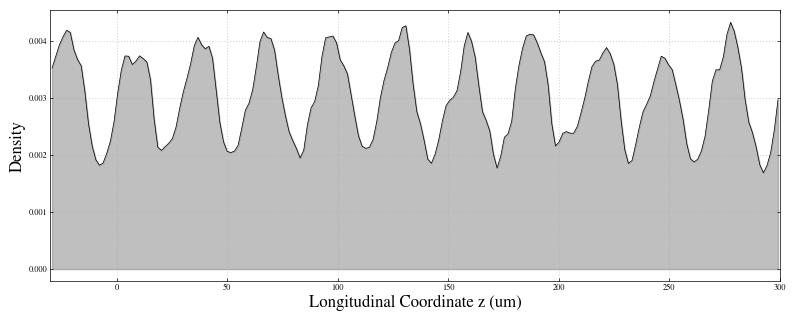

In [17]:
reload_kladov()
wavelength = 30e-6
tempP = kladov.make_simple_bunch_standalone(N=1e5, meanPzMeV=125, moments=[1e-3, 0.5e-3, 1e-3, 0.5e-3, 1e-3, 1e6], save_path = folder + 'temp_beam/temp', means=[0,0,0,0,0,0])
P = kladov.make_modulated_bunch(ParticleGroup(folder + "temp_beam/temp.h5"), wavelength=wavelength, mod_amplitude=0.5)

kladov.hist(-P.t*3e8*1e6, label='Longitudinal Coordinate z (um)', num_bins=200, xlim=[-30,300])

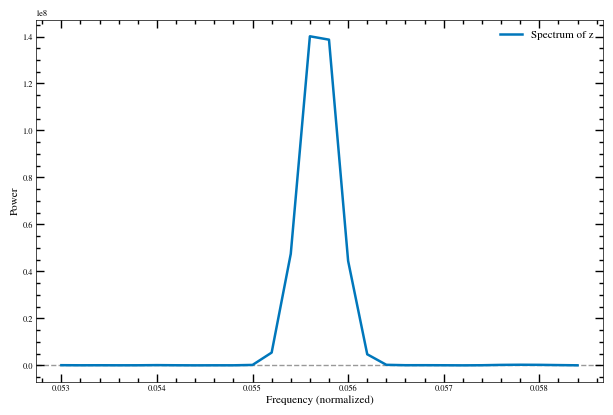

In [25]:
kladov.print_spec(P, 1.05*wavelength, 0.95*wavelength)

In [29]:
reload_kladov()
wavelength = 30e-6
tempP = kladov.make_simple_bunch_standalone(N=1e5, meanPzMeV=125, moments=[1e-3, 0.5e-3, 1e-3, 0.5e-3, 1e-3, 1e6], save_path = folder + 'temp_beam/temp', means=[0,0,0,0,0,0])
P1 = kladov.make_modulated_bunch(ParticleGroup(folder + "temp_beam/temp.h5"), wavelength=wavelength, mod_amplitude=0.1)

limits=[0.95*wavelength, 1.05*wavelength]
np.sqrt(float(kladov.get_microbunching_gain_from_beams(P1, P, limits[1], limits[0], limits[1], limits[0])))

/lscratch/kladov/tmp/ipykernel_1771791/2710001998.py:7: ComplexWarning: Casting complex values to real discards the imaginary part
  np.sqrt(float(kladov.get_microbunching_gain_from_beams(P1, P, limits[1], limits[0], limits[1], limits[0])))


np.float64(4.285346296824211)